# TP1 — Definición de mercado y análisis exploratorio

**Diplomatura en Ciencia de Datos · Mentoría ID90Travel**

En este notebook consolidamos el análisis exploratorio del dataset de búsquedas hoteleras de ID90Travel para determinar qué combinación de dimensiones genera grupos de observaciones donde los precios presentan un comportamiento homogéneo.

---

## 1. Configuración y carga de datos

In [2]:
import sys
from pathlib import Path
# Buscar la carpeta raíz donde se encuentra config.py
for p in [Path('.').resolve(), Path('.').resolve().parent, Path('.').resolve().parent.parent]:
    if (p / 'config.py').exists():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        break

import sqlite3
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import config

DB_PATH = Path(config.BASE_DIR) / 'data' / 'hotel_data.db'
OUTPUT_DIR = Path(config.BASE_DIR) / 'TP1' / 'outputs'

print(f'Base de datos: {DB_PATH}')
print(f'Outputs: {OUTPUT_DIR}')

Base de datos: /home/francisco/Documents/GITHUB/mentoria-id90/data/hotel_data.db
Outputs: /home/francisco/Documents/GITHUB/mentoria-id90/TP1/outputs


In [3]:
# Verificar que la DB existe
if not DB_PATH.exists():
    print(' Ejecutar primero: python database.py')
else:
    conn = sqlite3.connect(str(DB_PATH))
    count = conn.execute('SELECT COUNT(*) FROM raw_data').fetchone()[0]
    print(f' Registros en DB: {count:,}')
    conn.close()

 Registros en DB: 5,158,190


## 2. Descripción general del dataset

El dataset contiene registros de búsquedas hoteleras de ID90Travel con la siguiente estructura:
- **5,1M de registros** correspondiente al período 2024-2025
- **~26.000 ciudades** distintas en estado crudo
- **Variables clave**: precio, oferta (cantidad de hoteles disponibles) y demanda (frecuencia de búsqueda)

In [4]:
# Cargar datos base con mapping
conn = sqlite3.connect(str(DB_PATH))
mapping_df = pd.read_csv(config.DESTINATION_MAPPING_FILE)
mapping_df.to_sql('mapping', conn, if_exists='replace', index=False)

query = """
WITH valid_data AS (
    SELECT * FROM raw_data
    WHERE nights > 0 AND number_of_rooms > 0 
    AND (number_of_adults + number_of_kids) > 0
),
standardized AS (
    SELECT *,
        avg_price_average / (nights * number_of_rooms * 
            MAX(number_of_adults + number_of_kids, 1)) as price_std,
        CAST(strftime('%w', date_start) AS INTEGER) as day_of_week,
        CAST(strftime('%m', date_start) AS INTEGER) as month,
        CASE 
            WHEN CAST(strftime('%d', date_start) AS INTEGER) <= 7 THEN 1
            WHEN CAST(strftime('%d', date_start) AS INTEGER) <= 15 THEN 2
            WHEN CAST(strftime('%d', date_start) AS INTEGER) <= 22 THEN 3
            ELSE 4
        END as week_in_month,
        CASE WHEN nights <= 2 THEN 'corta' WHEN nights <= 5 THEN 'media' ELSE 'larga' END as stay_duration
    FROM valid_data
),
with_dest AS (
    SELECT s.*, 
        COALESCE(m3.nearest_destination_id, m2.nearest_destination_id, m1.nearest_destination_id, s.city) as destination_final,
        COALESCE(m3.nearest_destination_name, m2.nearest_destination_name, m1.nearest_destination_name, s.city) as destination_name
    FROM standardized s
    LEFT JOIN mapping m3 ON UPPER(s.country_code) || ' - ' || UPPER(s.state) || ' - ' || s.city = m3.reference
    LEFT JOIN mapping m2 ON UPPER(s.country_code) || ' - ' || s.city = m2.reference
    LEFT JOIN mapping m1 ON UPPER(s.country_code) || ' - ' || UPPER(s.state) = m1.reference
)
SELECT * FROM with_dest WHERE destination_final IS NOT NULL
"""

df = pd.read_sql_query(query, conn)
conn.close()

print(f' Registros válidos: {len(df):,}')
print(f' Destinos únicos: {df["destination_final"].nunique():,}')
print(f' Rango de fechas: {df["date_start"].min()} a {df["date_start"].max()}')
print(f'\n Estadísticas de precio normalizado:')
print(df['price_std'].describe().round(2))

 Registros válidos: 5,158,190
 Destinos únicos: 29,086
 Rango de fechas: 2024-01-01 a 2025-12-30

 Estadísticas de precio normalizado:
count    5158190.00
mean          62.53
std         1532.32
min            0.02
25%           17.96
50%           34.34
75%           63.04
max      2183823.49
Name: price_std, dtype: float64


## 3. Pregunta 1: ¿Qué define a un mercado hotelero?

**Objetivo**: identificar la combinación de dimensiones que genera grupos homogéneos dentro de los cuales la comparación de precios resulta consistente.

### 3.1 Dimensión geográfica

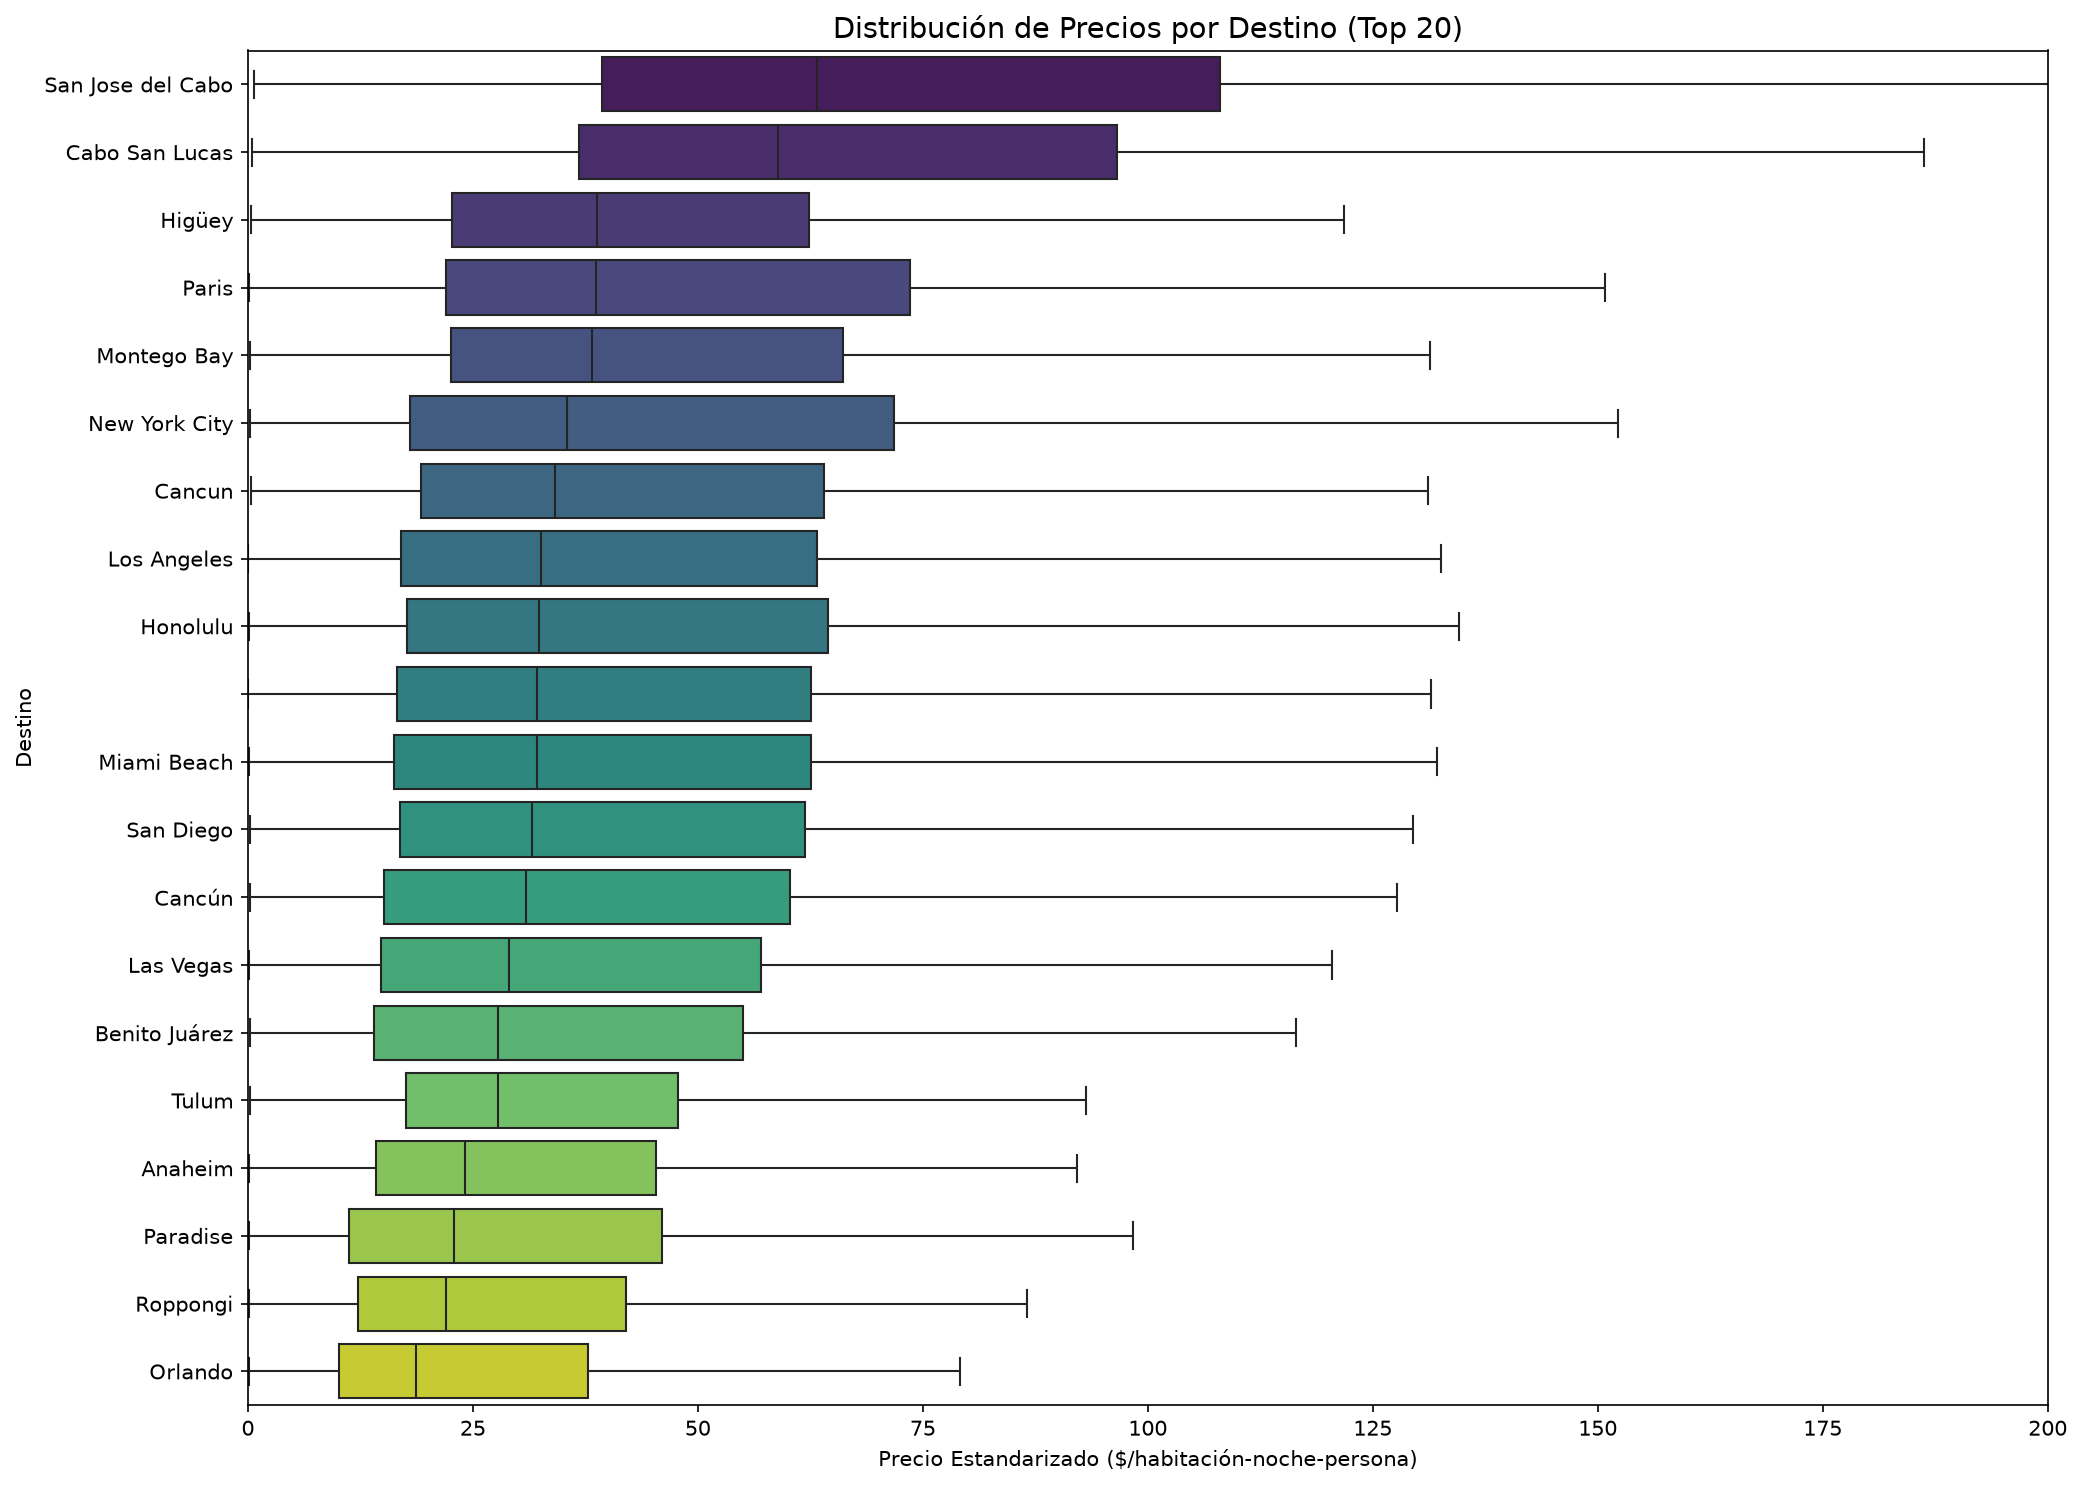

.Boxplot de precios por destino


In [5]:
# Boxplot de precios por destino (top 20)
img_path = OUTPUT_DIR / 'images' / '12_boxplot_precios_por_destino.png'
if img_path.exists():
    from IPython.display import Image, display
    display(Image(filename=str(img_path)))
    print('.Boxplot de precios por destino')
else:
    print(' Ejecutar: python TP1/scripts/12_distribucion_precios_por_destino.py')

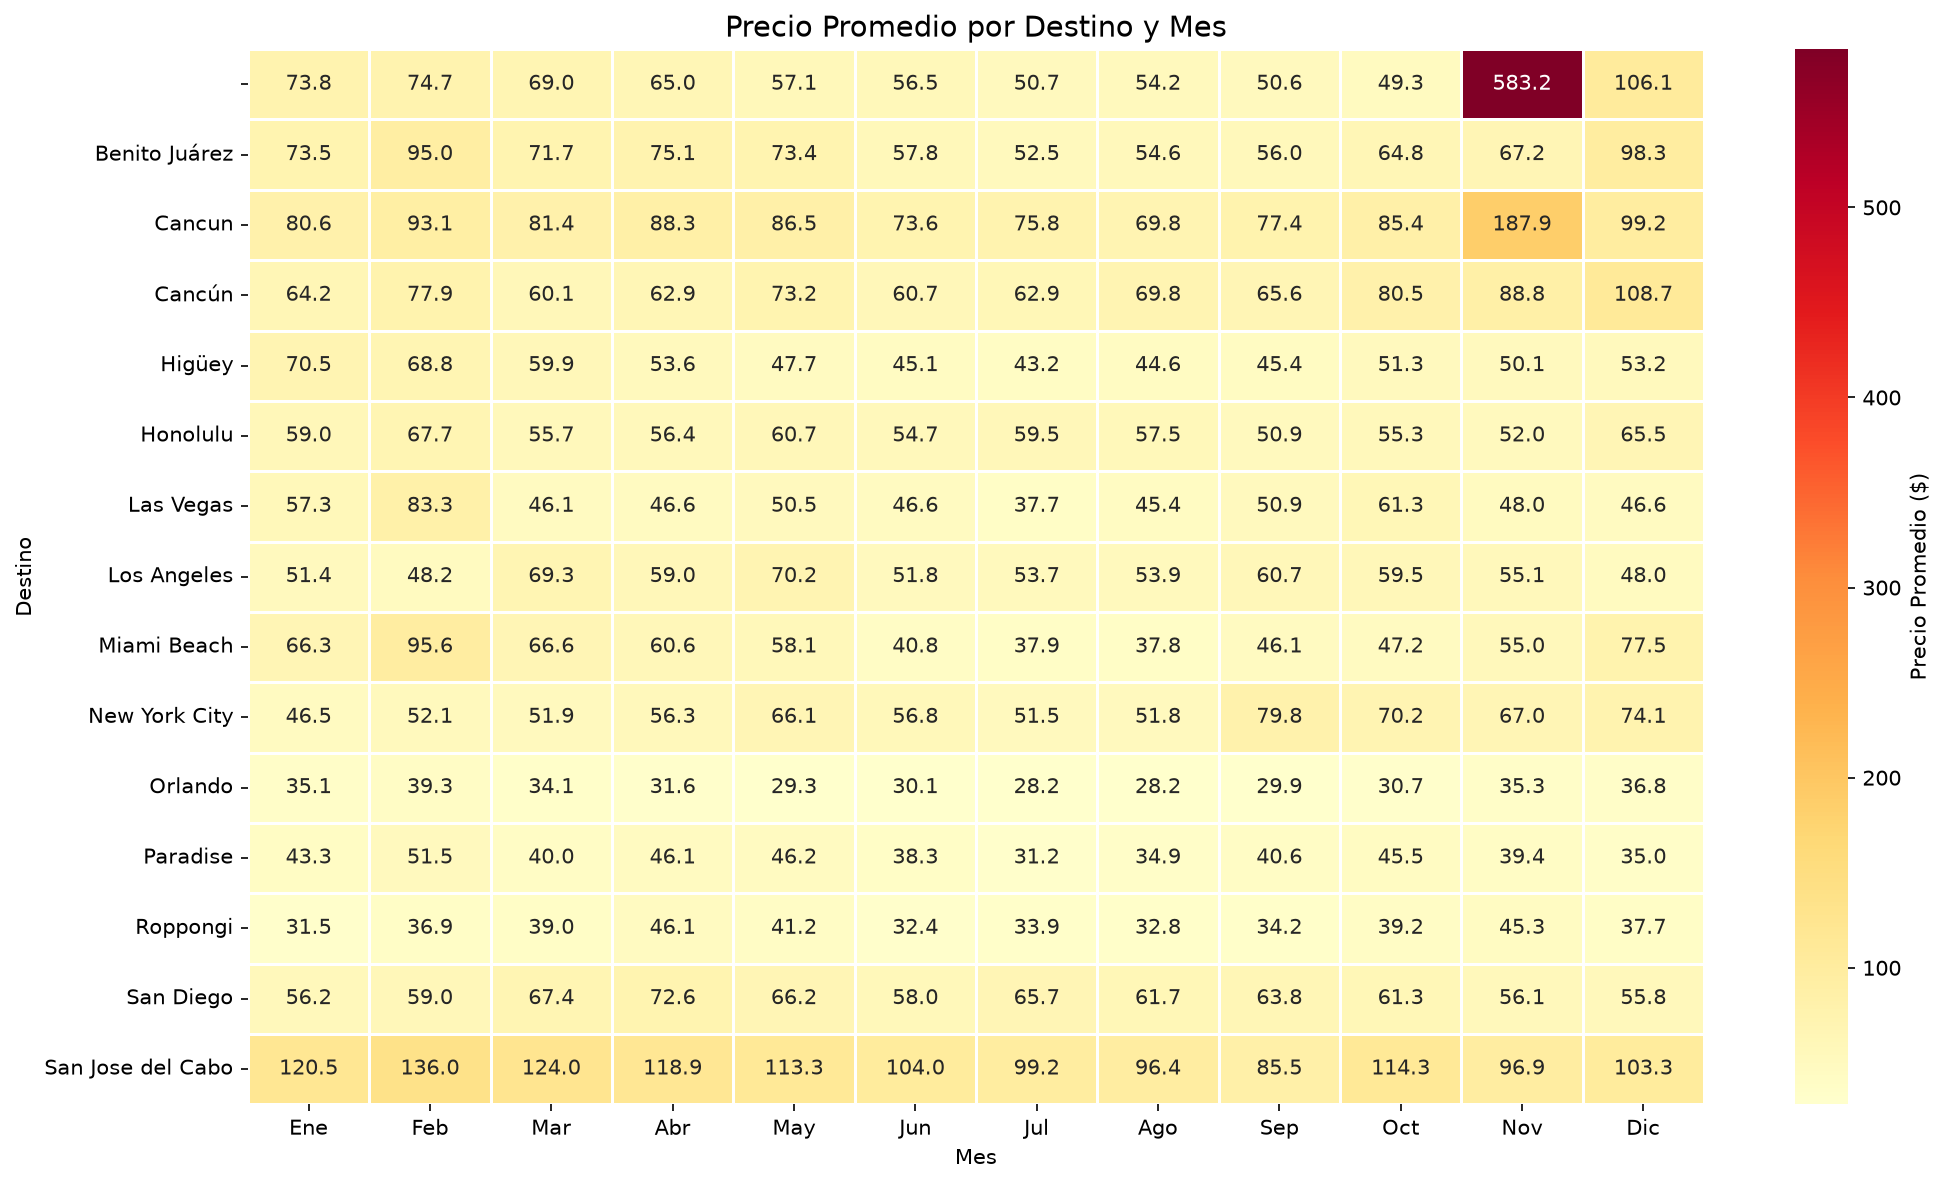

.Heatmap de precios por destino y mes


In [6]:
# Heatmap destino x mes
img_path = OUTPUT_DIR / 'images' / '12_heatmap_destino_mes.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print('.Heatmap de precios por destino y mes')
else:
    print(' Ejecutar: python TP1/scripts/12_distribucion_precios_por_destino.py')

### 3.2 Dimensión temporal

- **Día de la semana**: evaluamos si los sábados presentan tarifas más elevadas.
- **Mes del año**: analizamos la presencia de patrones estacionales.
- **Semana del mes**: comparamos las variaciones entre la primera y la tercera semana de cada mes.

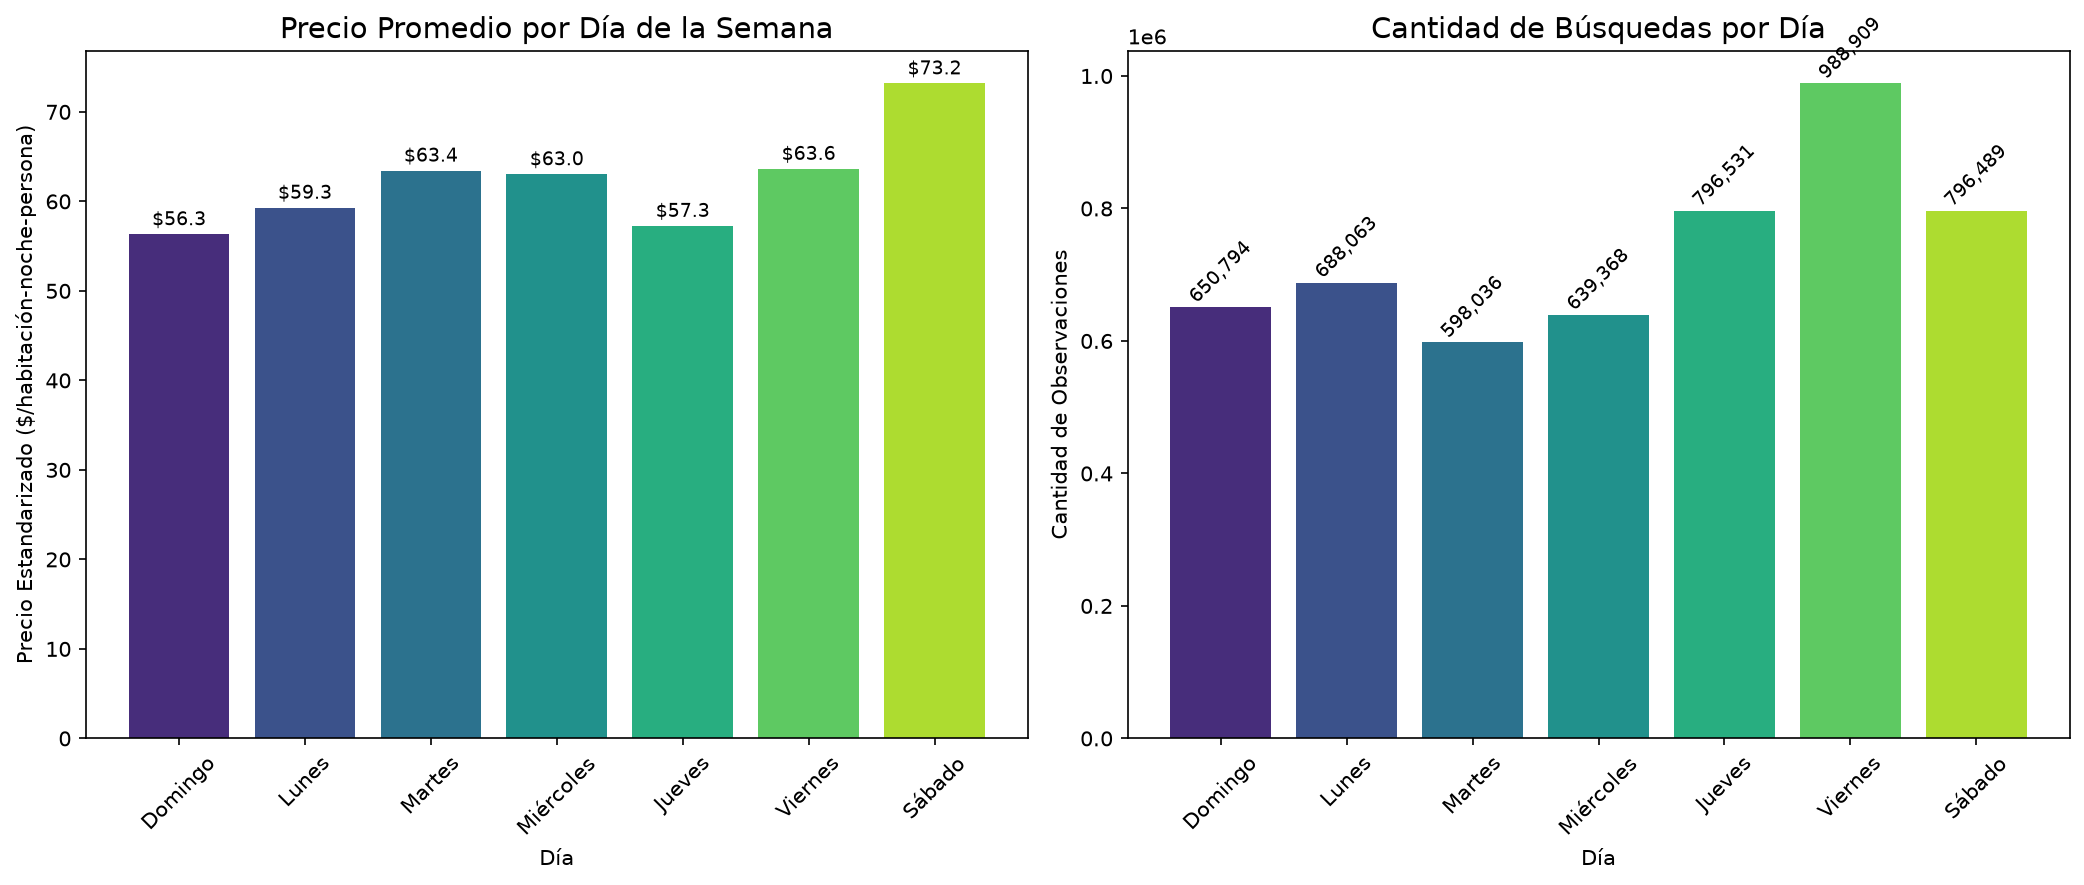

 Precio por día de la semana


In [7]:
# Precio por día de la semana
img_path = OUTPUT_DIR / 'images' / '09_precio_por_dia_semana.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Precio por día de la semana')
else:
    print(' Ejecutar: python TP1/scripts/09_analisis_dia_semana_precio.py')

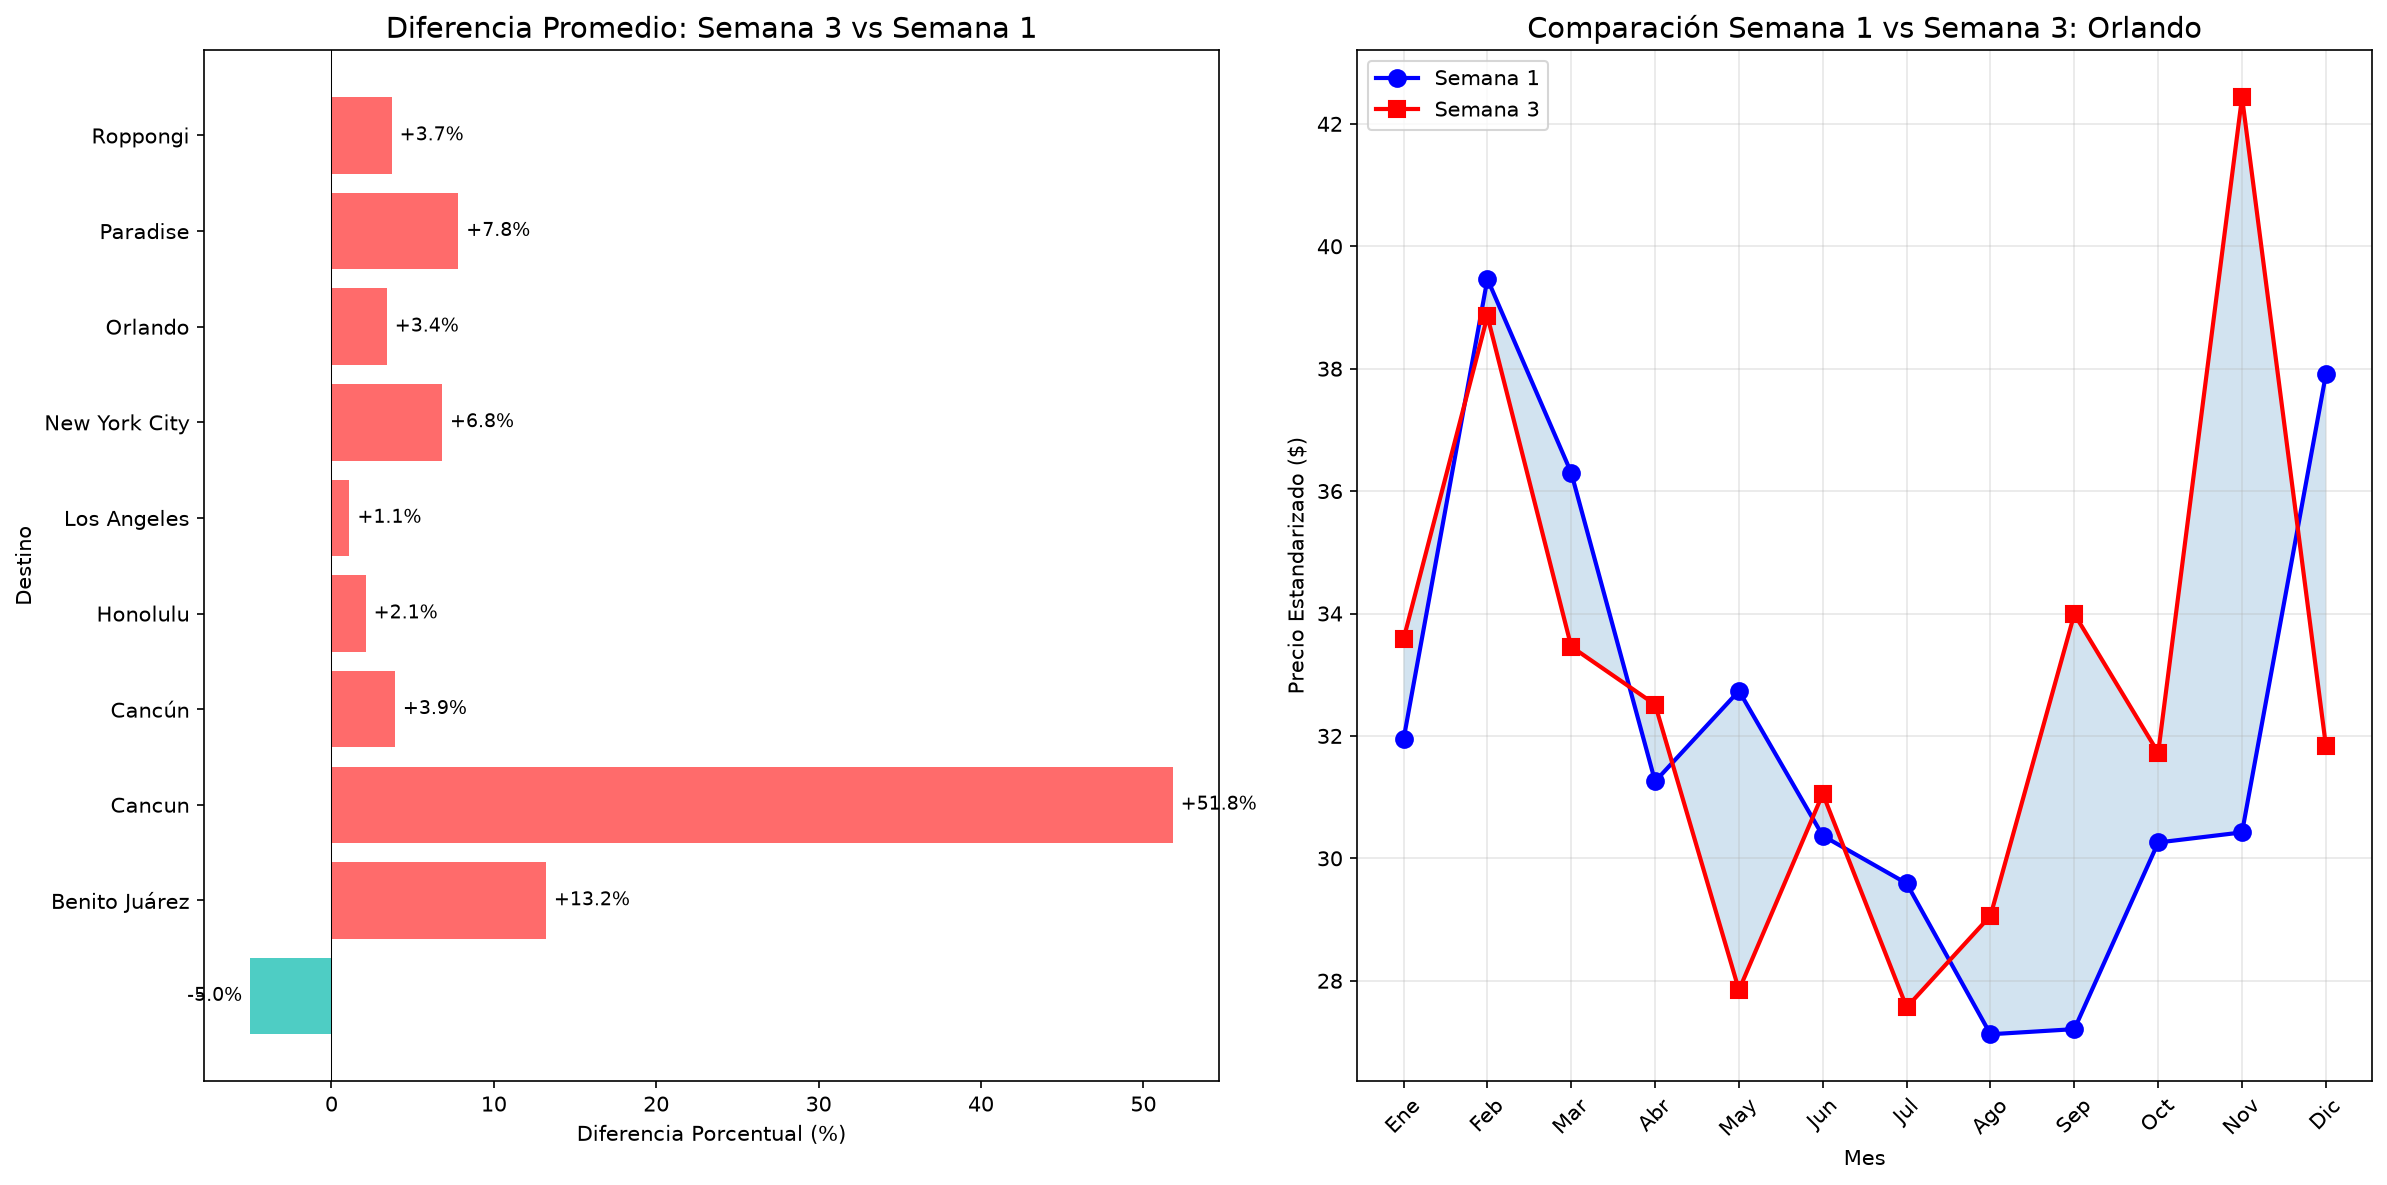

 Comparación Semana 1 vs Semana 3


In [8]:
# Patrones semanales
img_path = OUTPUT_DIR / 'images' / '16_patrones_semanales.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Comparación Semana 1 vs Semana 3')
else:
    print(' Ejecutar: python TP1/scripts/16_patrones_semanales.py')

### 3.3 Dimensión de oferta y demanda

- **`avg_hotel_count` (oferta)**: analizamos si un mayor volumen de hoteles disponibles reduce el precio normalizado.
- **`count_repeated` (demanda)**: evaluamos si las búsquedas más frecuentes exhiben tarifas diferenciadas.

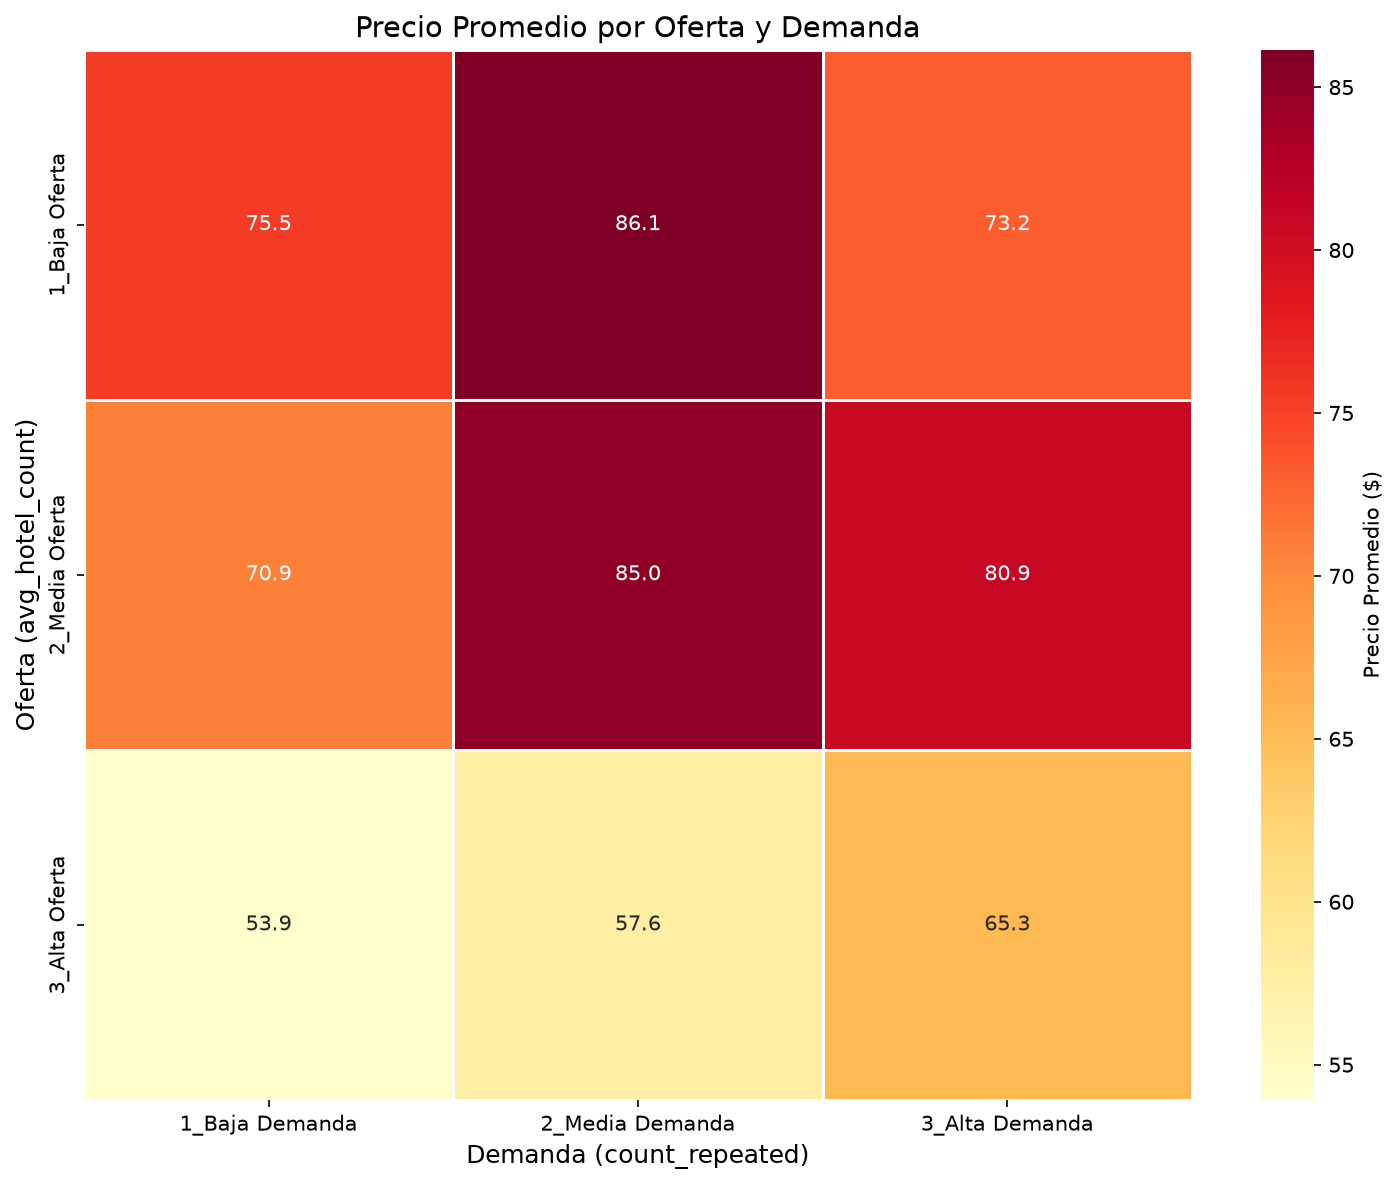

 Precio por oferta y demanda


In [9]:
# Heatmap oferta vs demanda vs precio
img_path = OUTPUT_DIR / 'images' / '18_heatmap_oferta_demanda_precio.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Precio por oferta y demanda')
else:
    print(' Ejecutar: python TP1/scripts/18_dimensiones_relevantes.py')

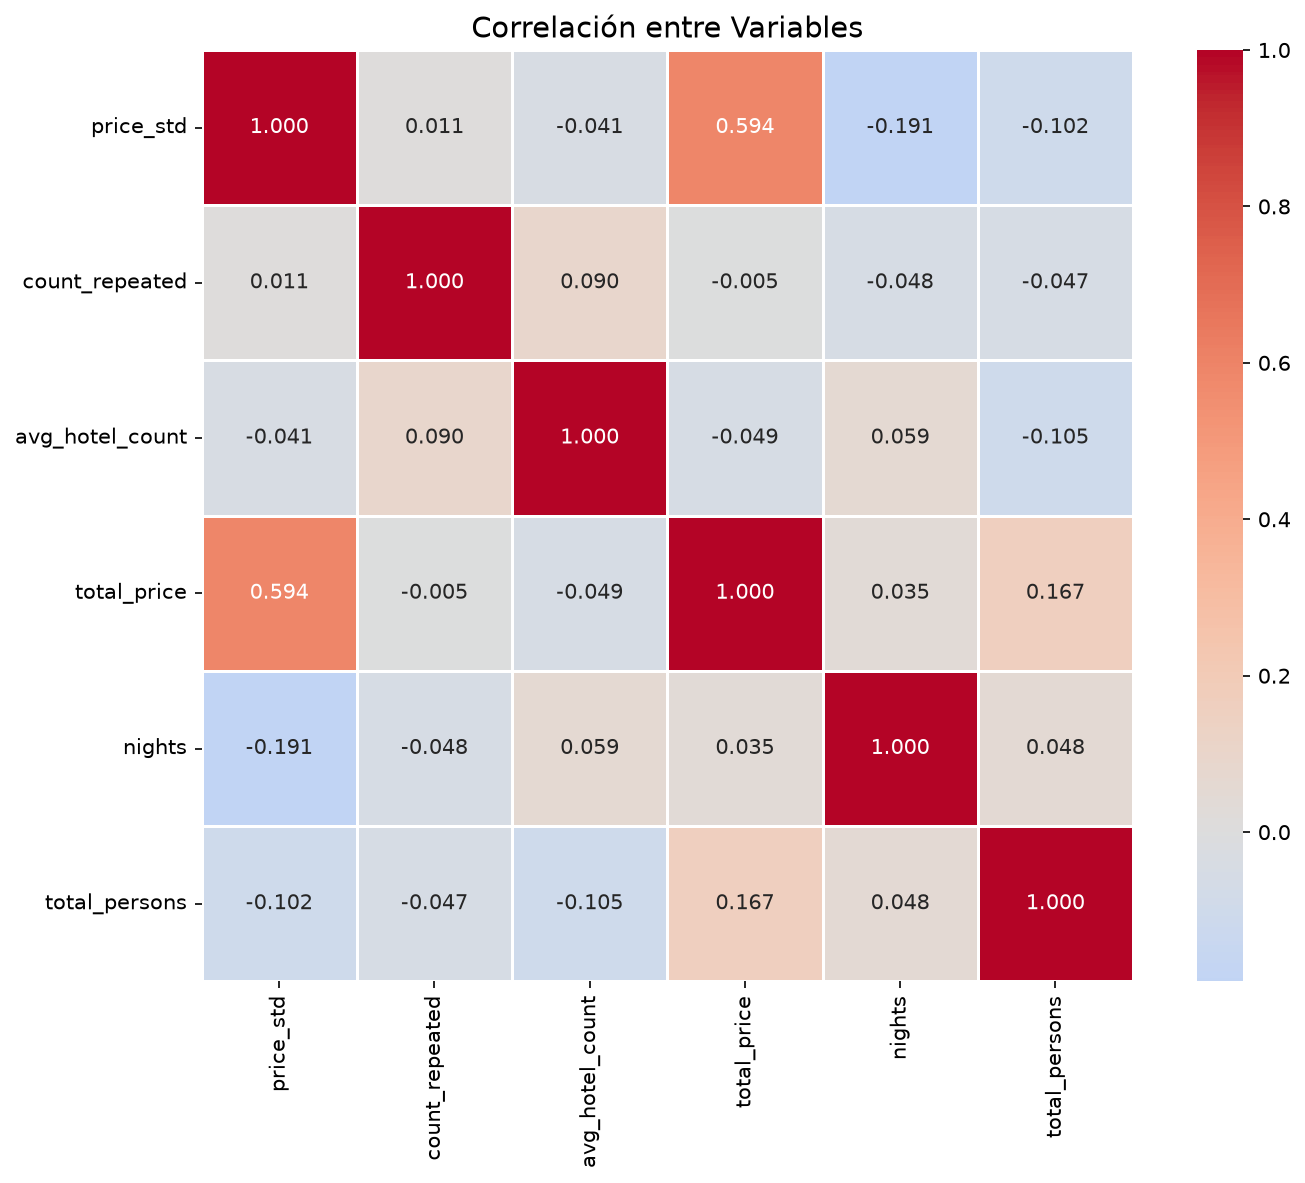

 Matriz de correlación entre variables


In [10]:
# Correlaciones
img_path = OUTPUT_DIR / 'images' / '13_matriz_correlacion.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Matriz de correlación entre variables')
else:
    print(' Ejecutar: python TP1/scripts/13_analisis_demanda_oferta.py')

### 3.4 Dimensión de duración de estadía

Evaluamos la presencia de descuentos por volumen y comprobamos si el precio por noche varía en función de la cantidad total de noches reservadas.

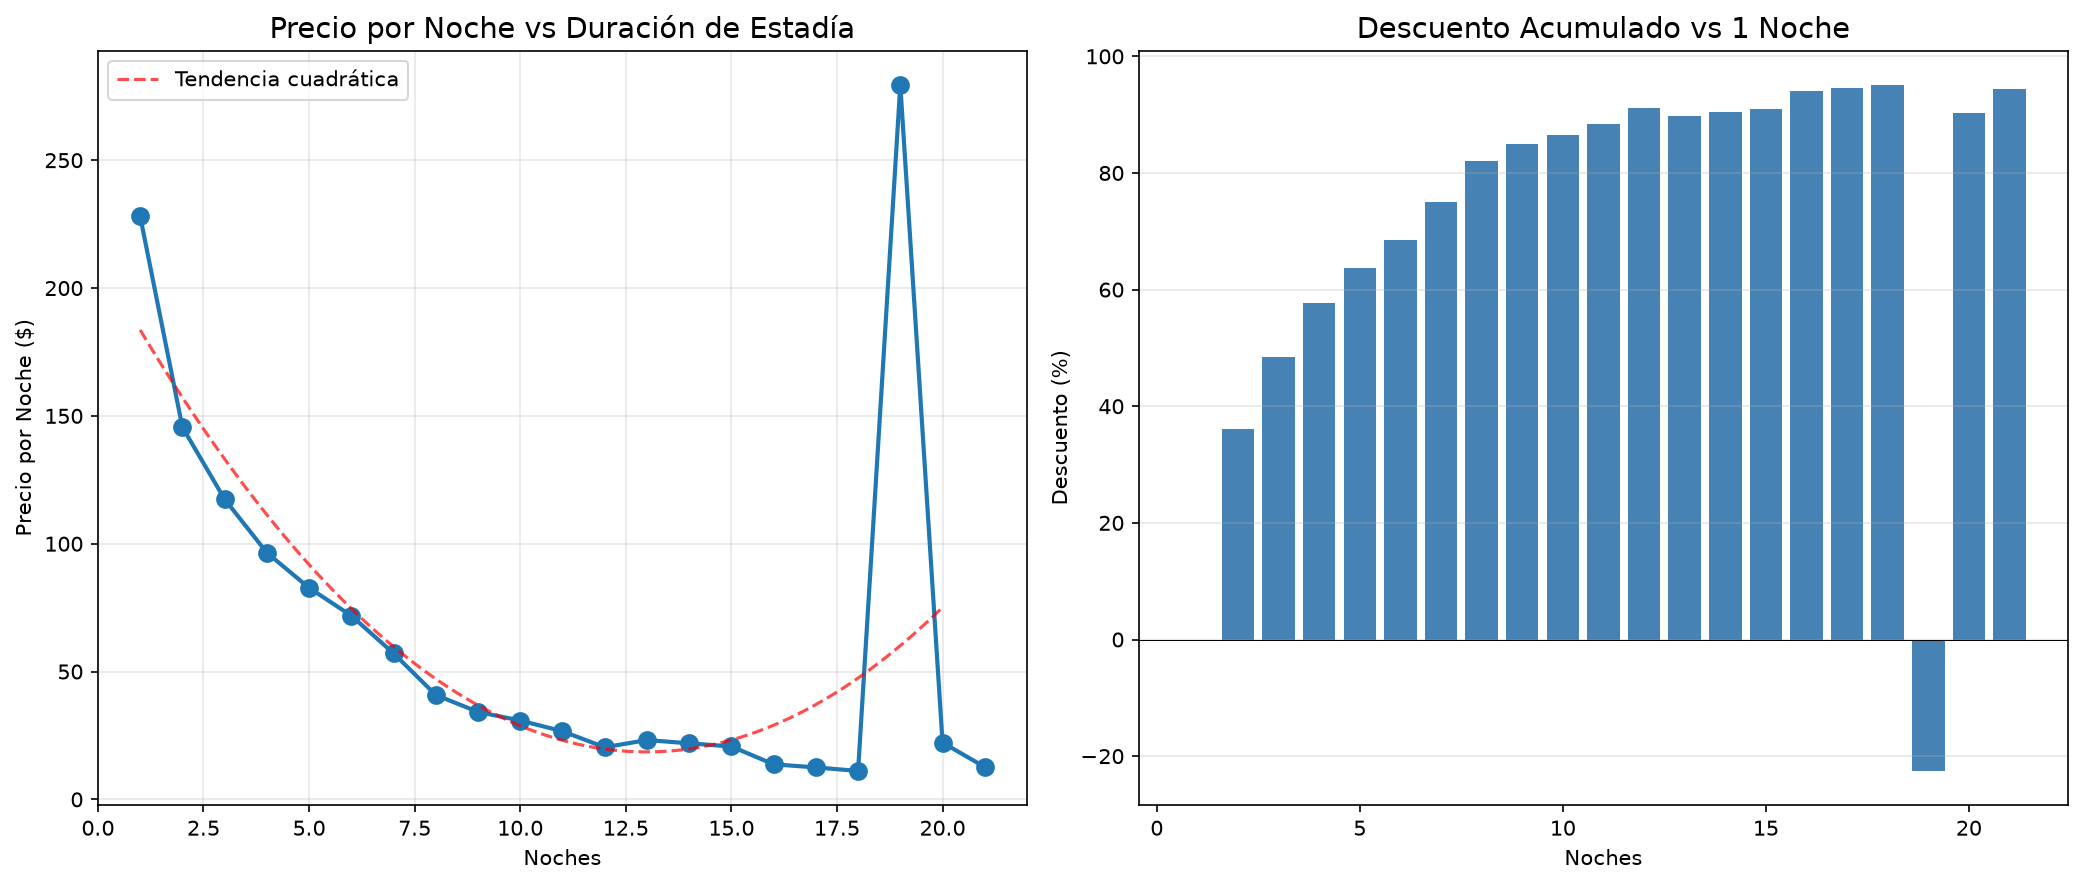

 Descuentos por volumen de estadía


In [11]:
# Descuentos por volumen
img_path = OUTPUT_DIR / 'images' / '18_descuentos_volumen.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Descuentos por volumen de estadía')
else:
    print(' Ejecutar: python TP1/scripts/18_dimensiones_relevantes.py')

## 4. Análisis de homogeneidad

Para determinar qué combinación de dimensiones genera grupos donde los precios resultan comparables, calculamos la relación señal-ruido o **Signal-to-Noise Ratio (SNR)**. Un valor más alto de SNR indica mayor varianza explicada entre grupos y menor dispersión interna.

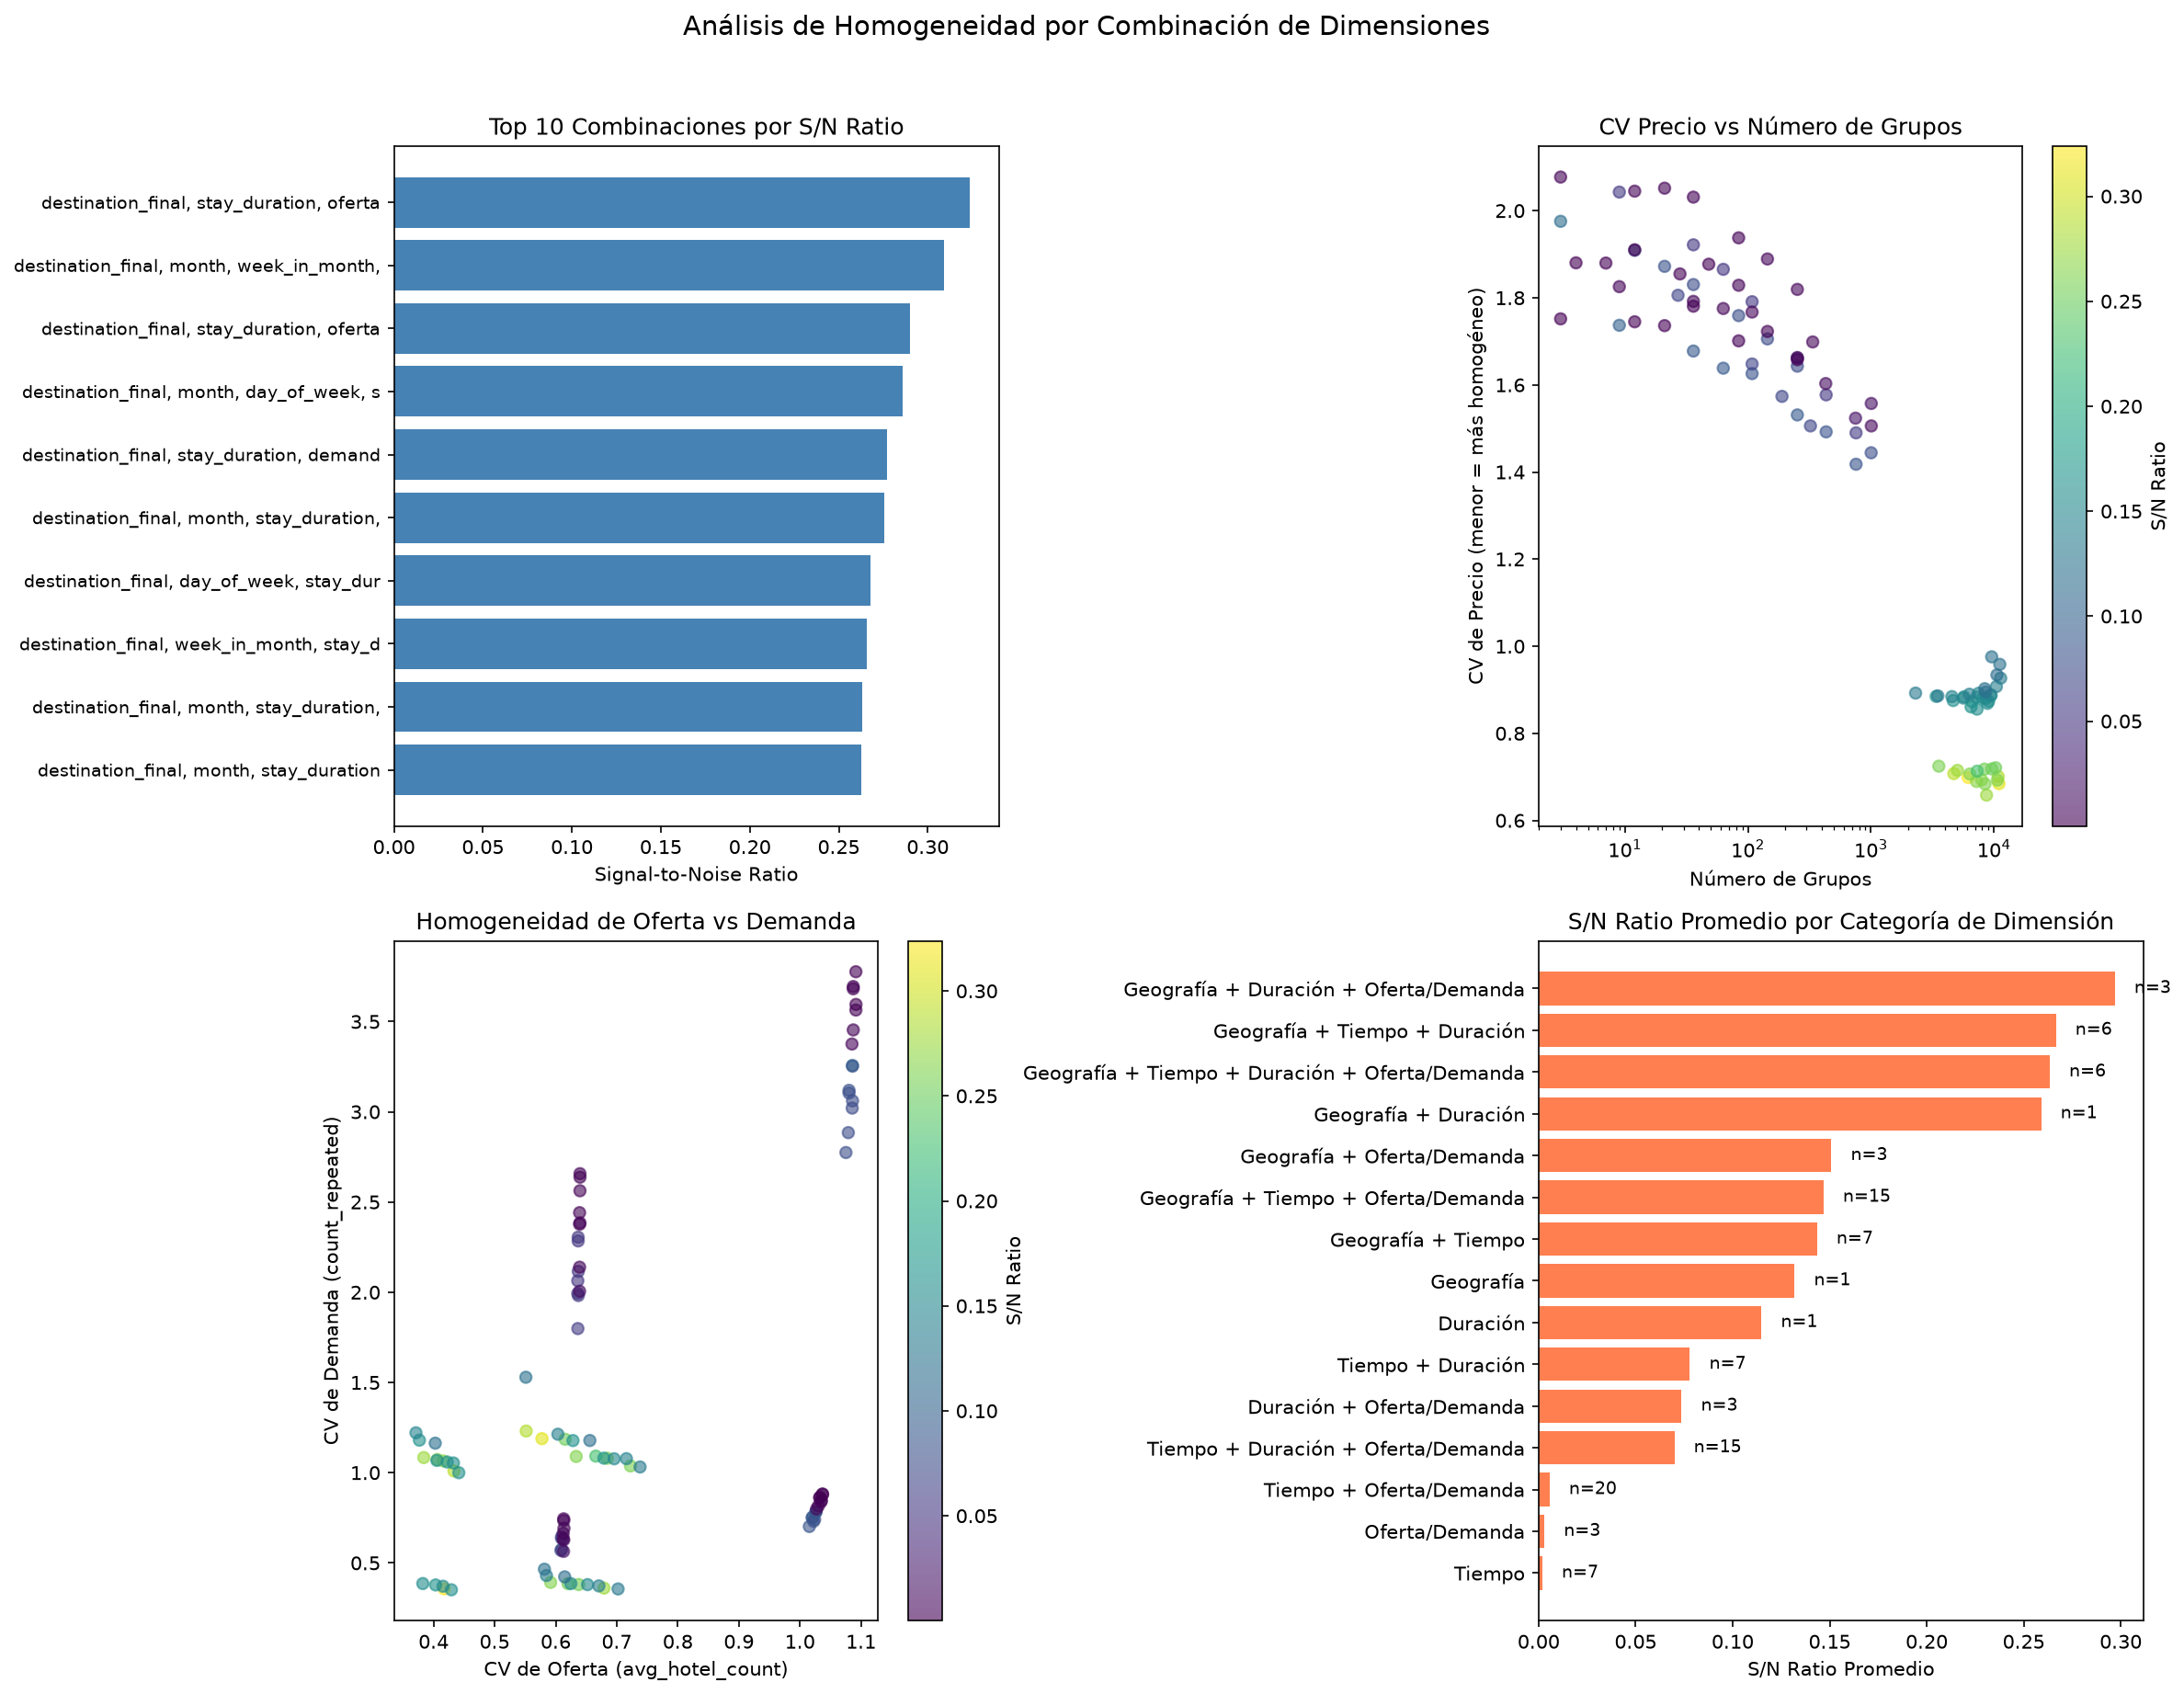

 Análisis de homogeneidad por combinación de dimensiones


In [12]:
# Resultados de homogeneidad
img_path = OUTPUT_DIR / 'images' / '17_homogeneidad_dimensiones.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Análisis de homogeneidad por combinación de dimensiones')
else:
    print(' Ejecutar: python TP1/scripts/17_homogeneidad_dimensiones.py')

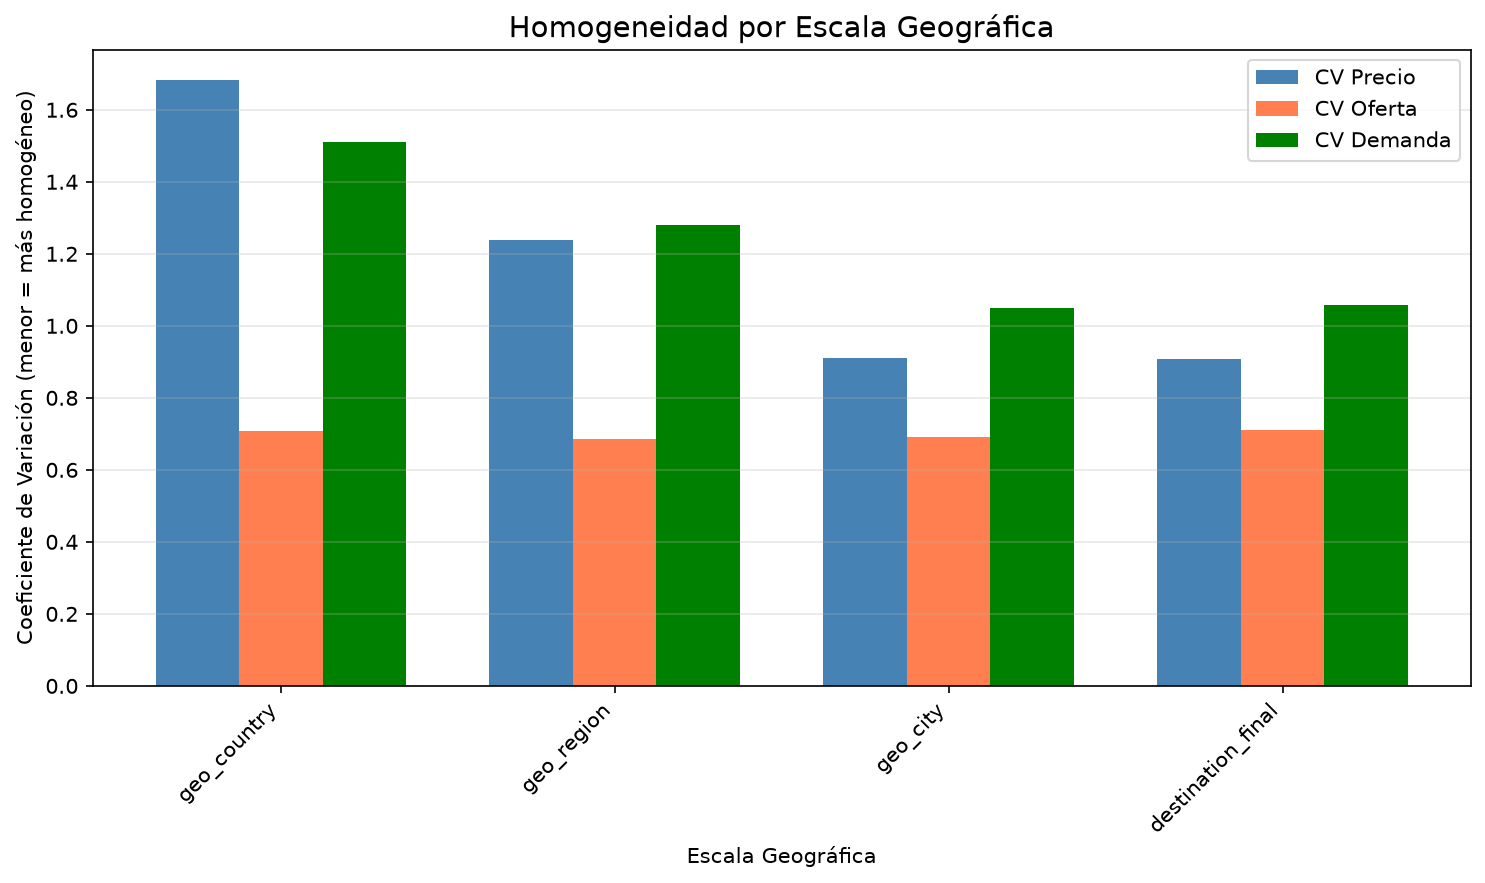

 Homogeneidad por escala geográfica


In [13]:
# Escala geográfica
img_path = OUTPUT_DIR / 'images' / '17_homogeneidad_escala_geografica.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Homogeneidad por escala geográfica')
else:
    print(' Ejecutar: python TP1/scripts/17_homogeneidad_dimensiones.py')

In [14]:
# Ver top combinaciones
csv_path = OUTPUT_DIR / 'data' / '17_homogeneidad_dimensiones.csv'
if csv_path.exists():
    homog = pd.read_csv(csv_path)
    print(' Top 10 combinaciones por Signal-to-Noise Ratio:')
    print('='*80)
    for i, row in homog.head(10).iterrows():
        print(f"{i+1:2d}. {row['dimensions'][:60]:<60} S/N={row['signal_noise_ratio']:.3f}")
else:
    print(' Ejecutar: python TP1/scripts/17_homogeneidad_dimensiones.py')

 Top 10 combinaciones por Signal-to-Noise Ratio:
 1. destination_final, stay_duration, oferta_bucket, demanda_buc S/N=0.324
 2. destination_final, month, week_in_month, stay_duration       S/N=0.309
 3. destination_final, stay_duration, oferta_bucket              S/N=0.290
 4. destination_final, month, day_of_week, stay_duration         S/N=0.286
 5. destination_final, stay_duration, demanda_bucket             S/N=0.277
 6. destination_final, month, stay_duration, oferta_bucket       S/N=0.275
 7. destination_final, day_of_week, stay_duration, oferta_bucket S/N=0.268
 8. destination_final, week_in_month, stay_duration, oferta_buck S/N=0.266
 9. destination_final, month, stay_duration, demanda_bucket      S/N=0.263
10. destination_final, month, stay_duration                      S/N=0.263


## 5. Pregunta 2: ¿Cuántos destinos poseen baselines confiables?

**Criterio de suficiencia estadística**: consideramos que un baseline es confiable si cuenta con $\ge 30$ observaciones por contexto ($\text{destino} \times \text{mes} \times \text{semana}$).

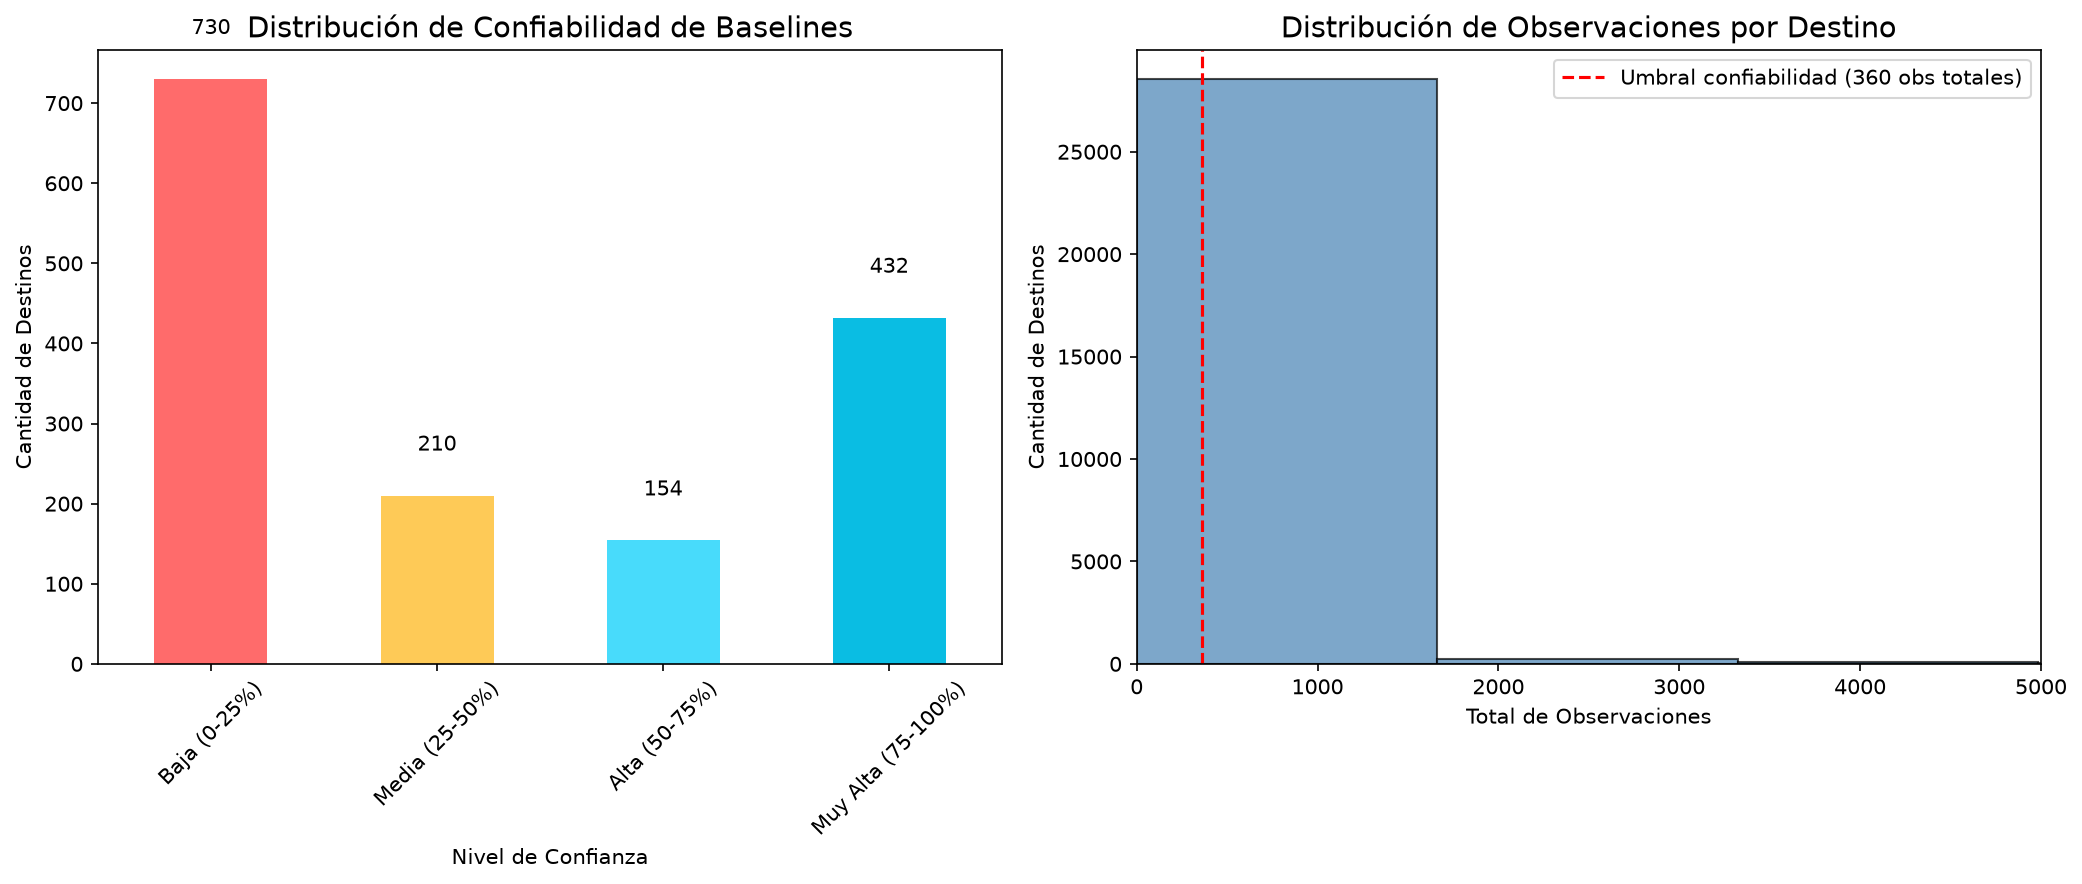

 Distribución de confiabilidad de baselines


In [15]:
# Confiabilidad de baselines
img_path = OUTPUT_DIR / 'images' / '14_confiabilidad_baselines.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Distribución de confiabilidad de baselines')
else:
    print(' Ejecutar: python TP1/scripts/14_baselines_confiables_y_mapeo.py')

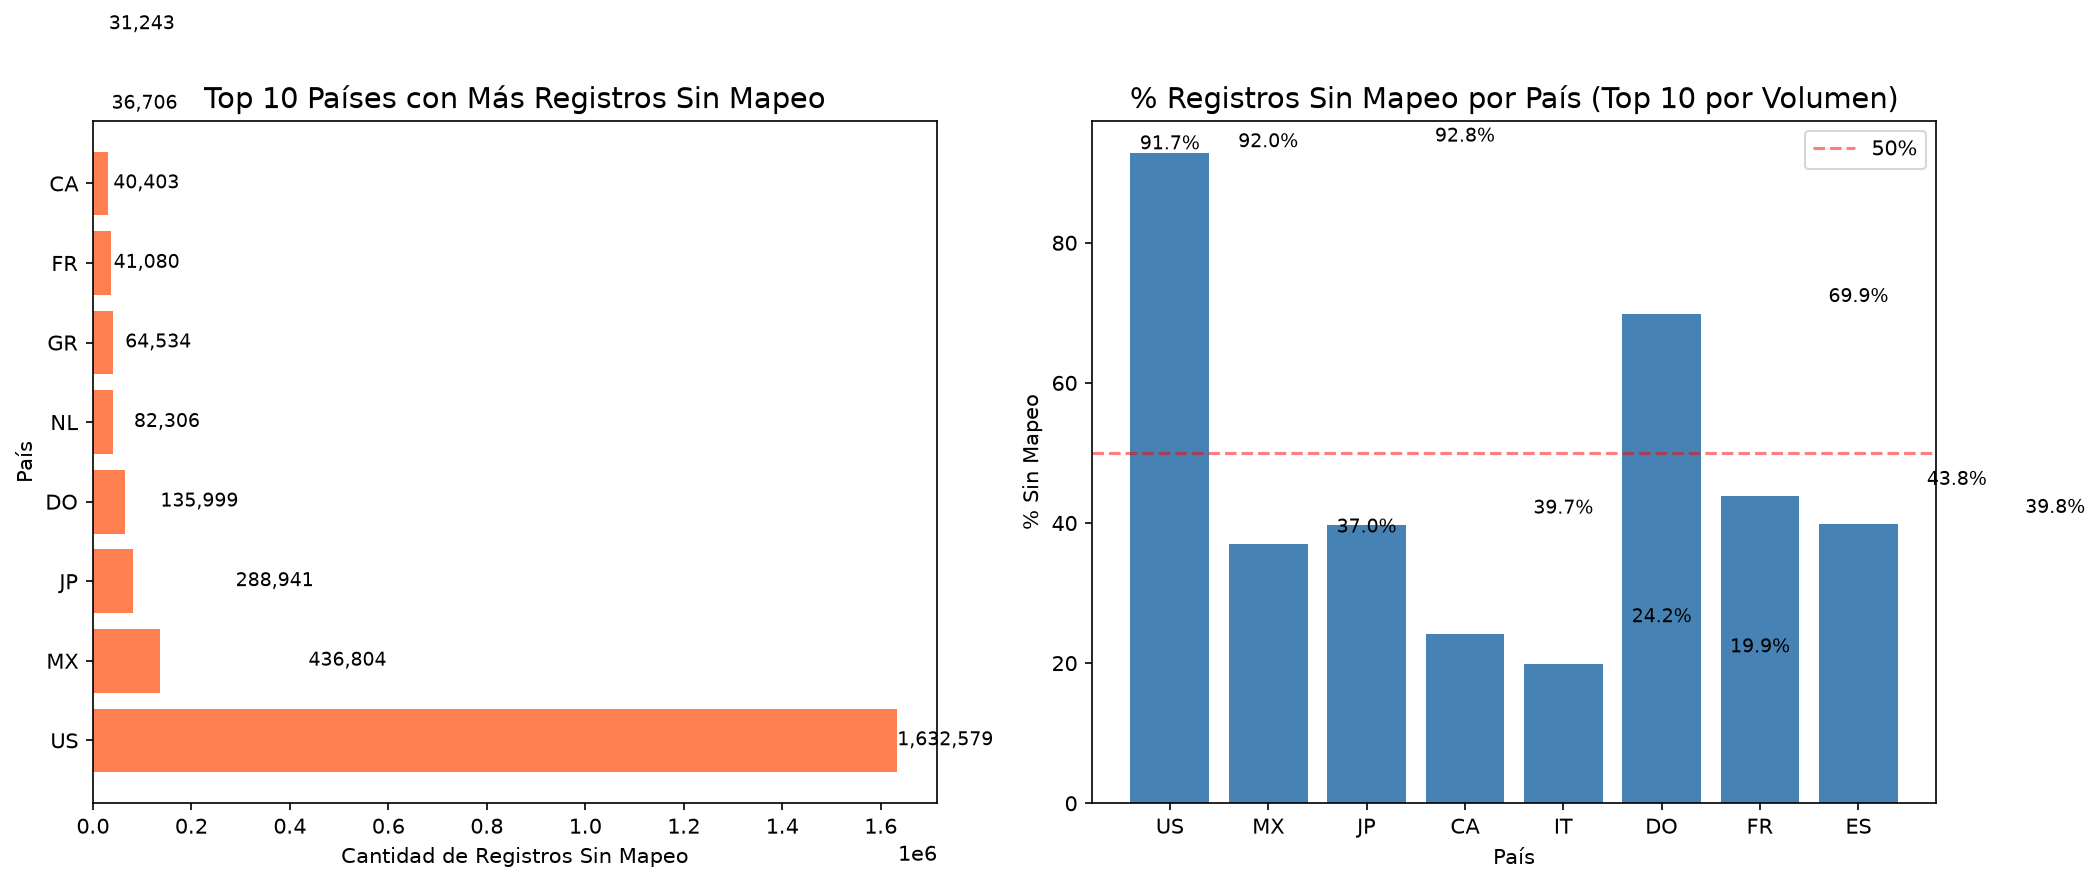

 Registros sin mapeo por país


In [16]:
# Registros sin mapeo
img_path = OUTPUT_DIR / 'images' / '14_registros_sin_mapeo_por_pais.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Registros sin mapeo por país')
else:
    print(' Ejecutar: python TP1/scripts/14_baselines_confiables_y_mapeo.py')

In [17]:
# Resumen de confiabilidad
csv_path = OUTPUT_DIR / 'data' / '14_confiabilidad_baselines.csv'
if csv_path.exists():
    conf = pd.read_csv(csv_path)
    total = len(conf)
    alta = len(conf[conf['pct_confiables'] >= 75])
    media = len(conf[(conf['pct_confiables'] >= 50) & (conf['pct_confiables'] < 75)])
    baja = len(conf[conf['pct_confiables'] < 50])
    
    print(f' Resumen de confiabilidad de baselines:')
    print(f' Total destinos: {total:,}')
    print(f' Alta confianza (≥75% contextos confiables): {alta:,} ({alta/total*100:.1f}%)')
    print(f' Media confianza (50-75%): {media:,} ({media/total*100:.1f}%)')
    print(f' Baja confianza (<50%): {baja:,} ({baja/total*100:.1f}%)')

 Resumen de confiabilidad de baselines:
 Total destinos: 29,086
 Alta confianza (≥75% contextos confiables): 441 (1.5%)
 Media confianza (50-75%): 158 (0.5%)
 Baja confianza (<50%): 28,487 (97.9%)


## 6. Visualización de baselines históricos

Analizamos el comportamiento de las tarifas históricas según el destino canónico.

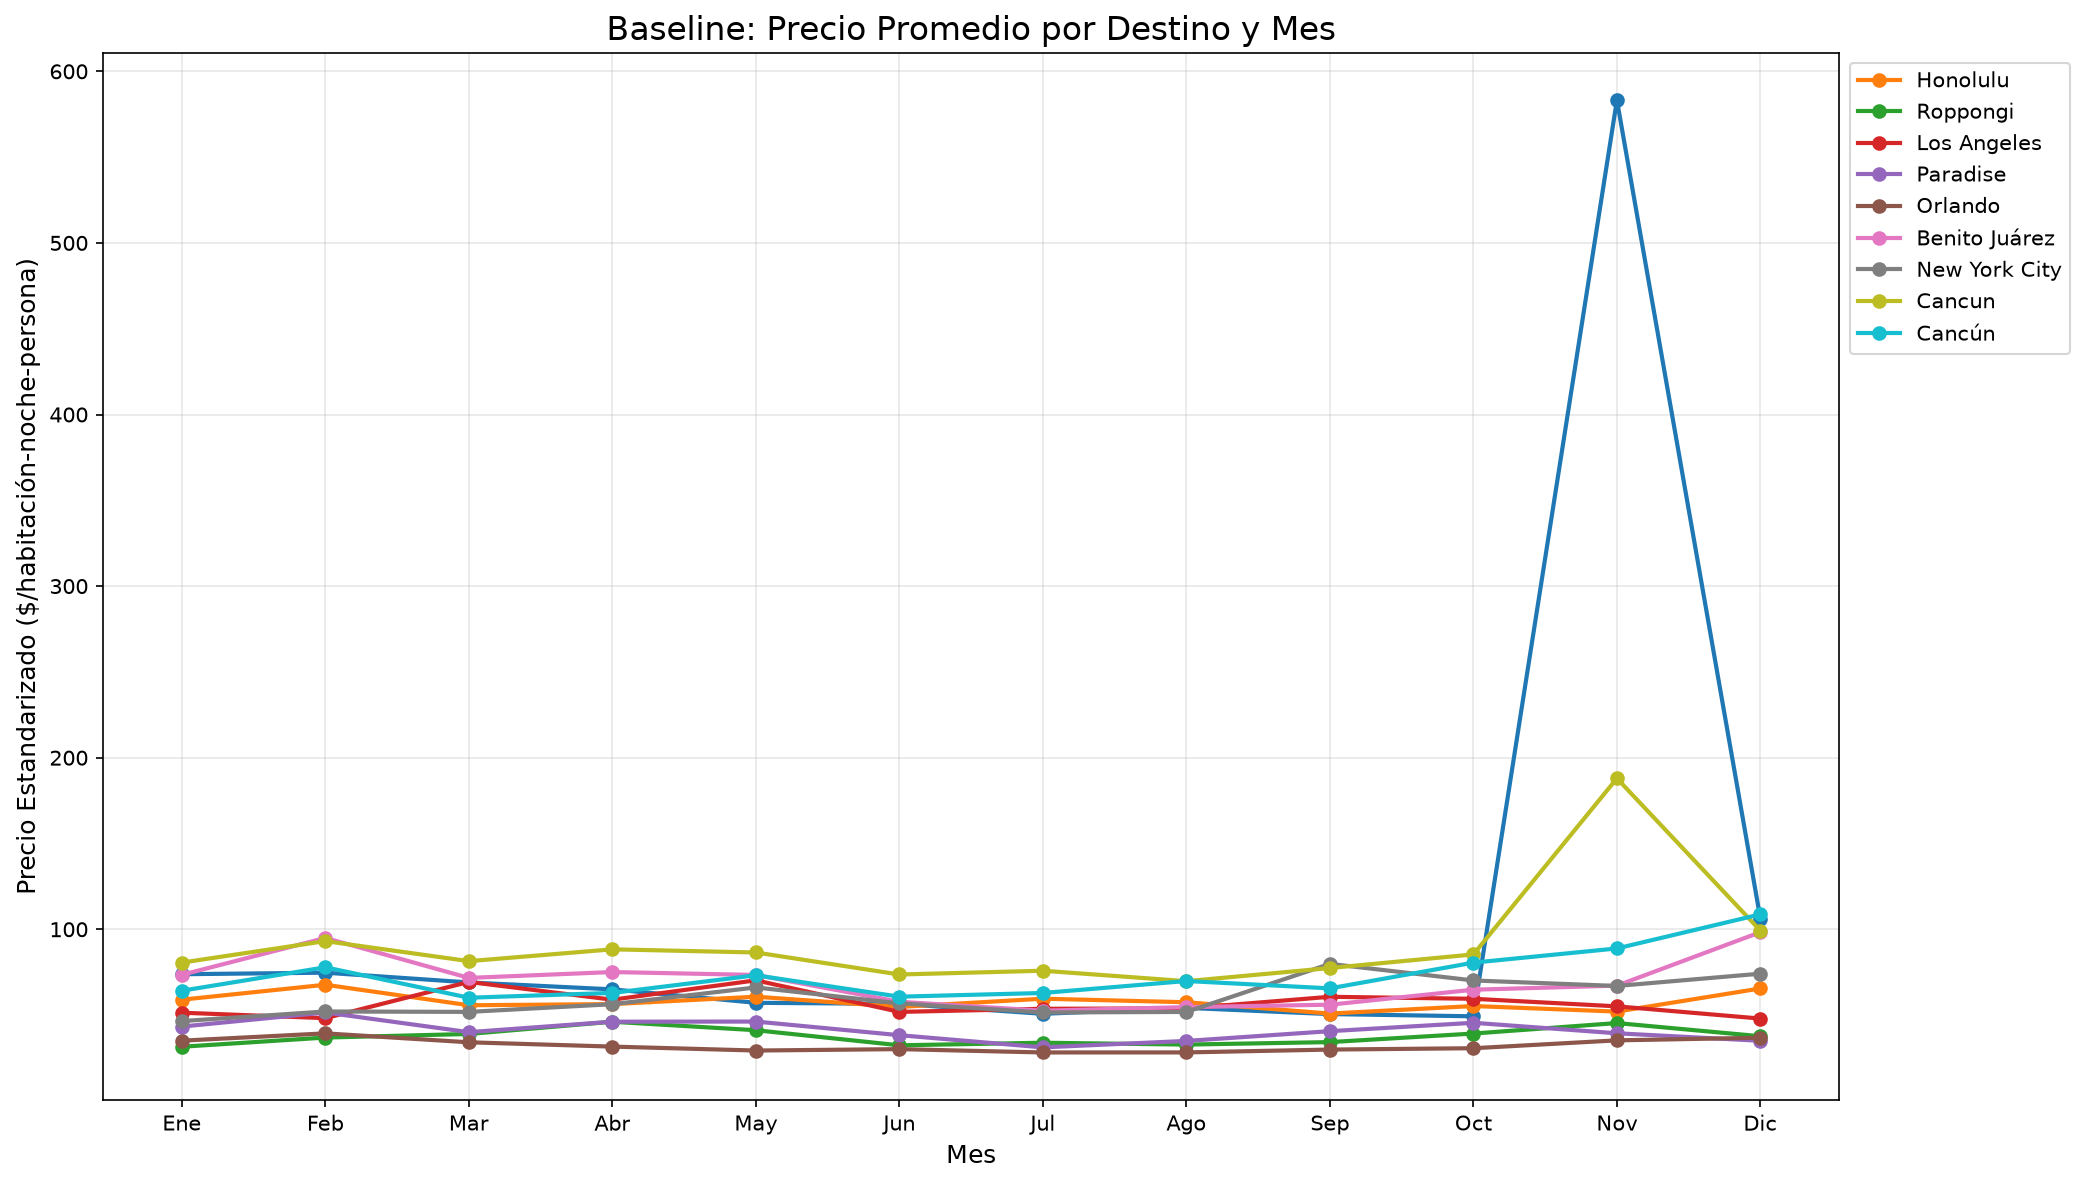

 Baselines: Precio promedio por destino y mes


In [18]:
# Líneas de baselines
img_path = OUTPUT_DIR / 'images' / '15_baselines_lineas_top_destinos.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Baselines: Precio promedio por destino y mes')
else:
    print(' Ejecutar: python TP1/scripts/15_visualizar_baselines.py')

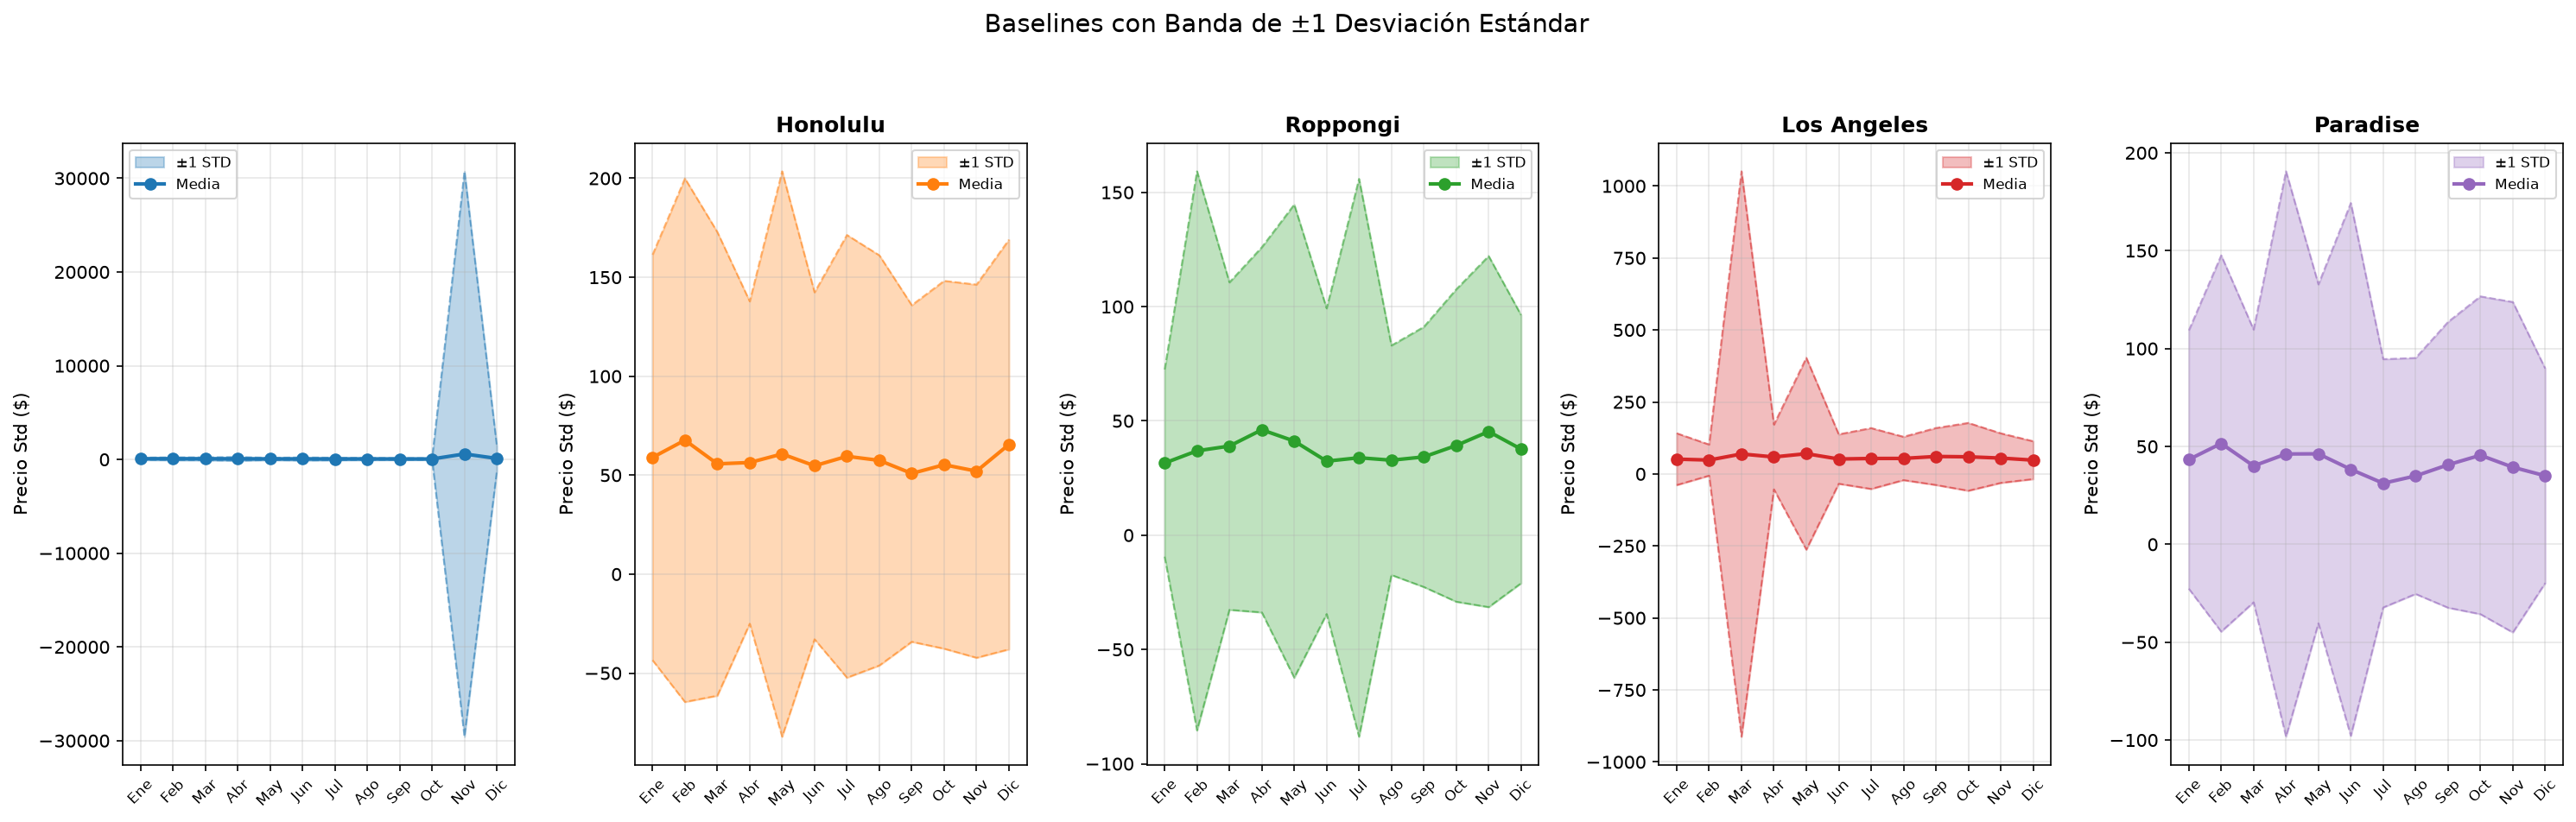

 Baselines con banda de ±1 desviación estándar


In [19]:
# Baselines con STD
img_path = OUTPUT_DIR / 'images' / '15_baselines_con_std.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Baselines con banda de ±1 desviación estándar')
else:
    print(' Ejecutar: python TP1/scripts/15_visualizar_baselines.py')

## 7. Hipótesis: segmentación de mercado propuesta

### Resumen de evidencia empírica

| Dimensión | Hallazgo empírico | Importancia para la segmentación |
|-----------|-------------------|----------------------------------|
| **Geografía (`destination_final`)** | Perfiles de precio heterogéneos entre destinos | **CRÍTICA** (Ancla fundamental del mercado) |
| **Mes del año (`month`)** | Estacionalidad marcada en zonas turísticas | **ALTA** (Captura variaciones por temporada) |
| **Semana del mes (`week_in_month`)** | Variaciones entre la primera y tercera semana del mes | **MEDIA** (Granularidad dentro del mes) |
| **Día de la semana (`day_of_week`)** | Sábados con mayor tarifa ($73) vs domingos ($56) en destinos de ocio | **MEDIA** (Patrón semanal de demanda) |
| **Duración de estadía (`stay_duration`)** | Disminución no lineal de la tarifa por noche en estadías largas | **ALTA** (Descuento por volumen no lineal) |
| **Oferta (`avg_hotel_count`)** | Reducción marginal del precio ante mayor disponibilidad | **MEDIA** (Efecto de competencia) |
| **Demanda (`count_repeated`)** | Correlación débil con el precio normalizado | **BAJA** (Indicador menos confiable) |

### Segmentación propuesta

$$\text{Contexto} = \text{destination\_final} \times \text{month} \times \text{week\_in\_month} \times \text{stay\_duration} [\times \text{price\_bucket}]$$

**Justificación del esquema**:
1. **Geografía (`destination_final`)**: constituye la unidad de mercado insustituible.
2. **Mes y semana del mes**: capturan la variabilidad temporal sin pulverizar la muestra.
3. **Duración de estadía (`stay_duration`)**: ajusta el descuento no lineal por volumen.

### Exclusión de oferta y demanda en la partición

Si bien la oferta y la demanda influyen en los precios, agregarlas como claves de particionado genera una fragmentación excesiva de los datos y reduce el número de observaciones por celda. Por lo tanto, conviene tratarlas como **variables de control**.

## 8. Validación e inspección interanual: 2024 vs 2025

Comprobamos si los patrones de comportamiento se mantienen estables entre 2024 y 2025 para validar la robustez de la segmentación propuesta.

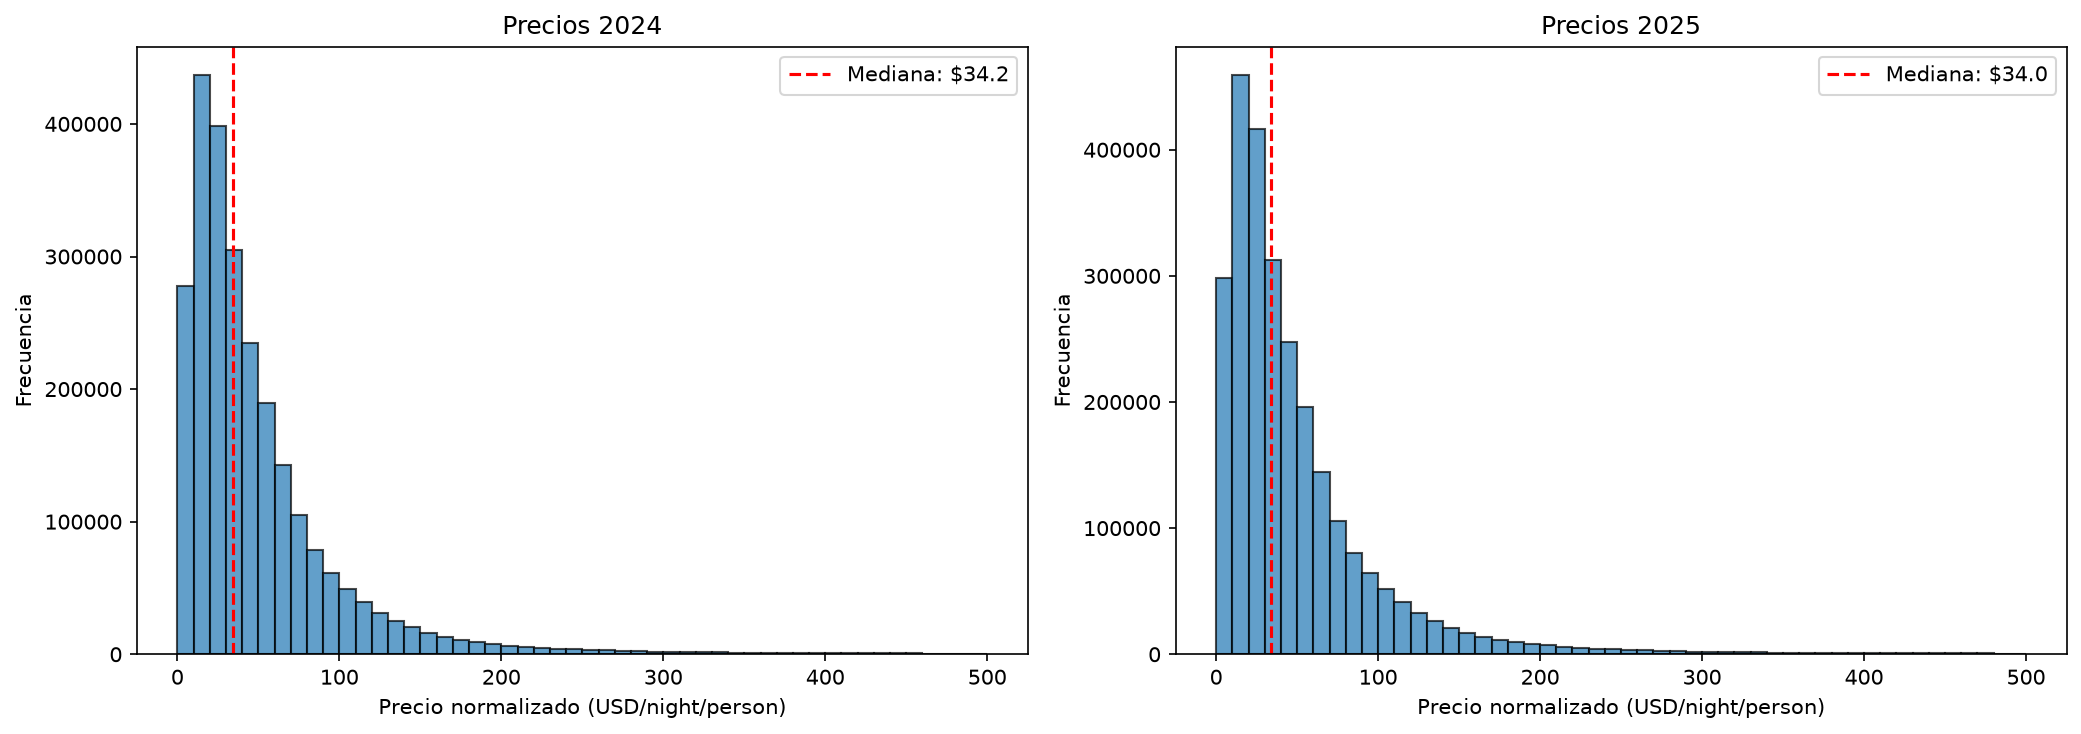

 Distribución de precios 2024 vs 2025


In [20]:
# Distribuciones de precios por año
img_path = OUTPUT_DIR / 'images' / '19c_distribucion_precios.png'
if img_path.exists():
    from IPython.display import Image, display
    display(Image(filename=str(img_path)))
    print(' Distribución de precios 2024 vs 2025')
else:
    print(' Ejecutar: python TP1/scripts/19c_comparacion_limpia.py')

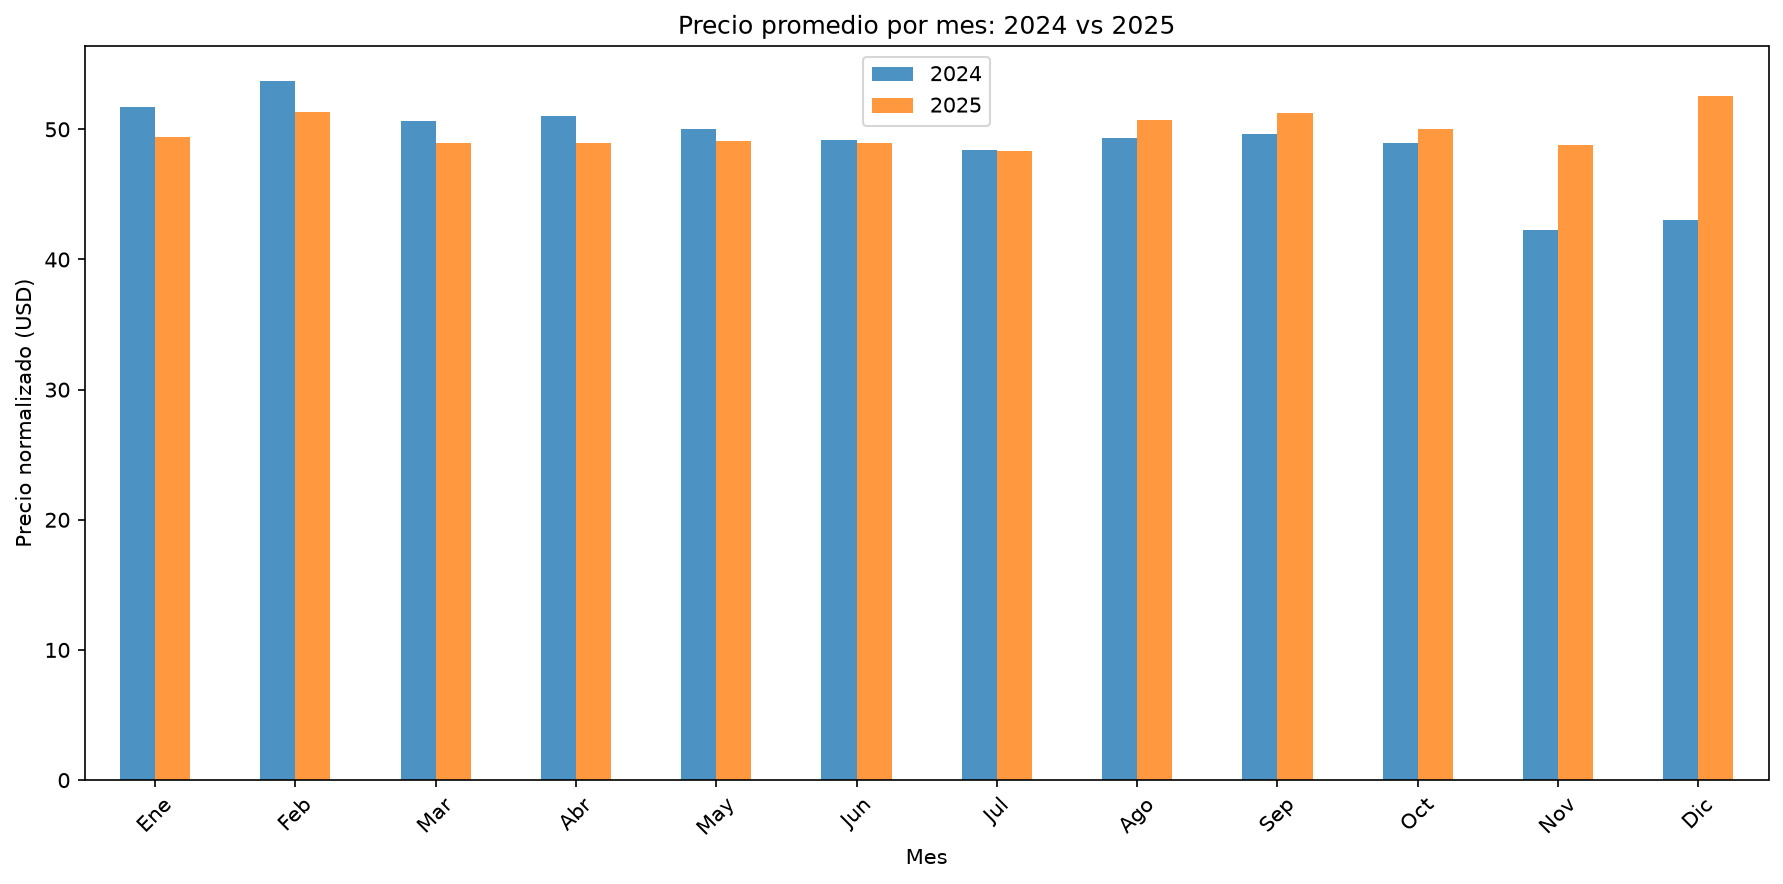

 Precio promedio por mes: 2024 vs 2025


In [21]:
# Patrón estacional por mes
img_path = OUTPUT_DIR / 'images' / '19c_precio_por_mes.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Precio promedio por mes: 2024 vs 2025')
else:
    print(' Ejecutar: python TP1/scripts/19c_comparacion_limpia.py')

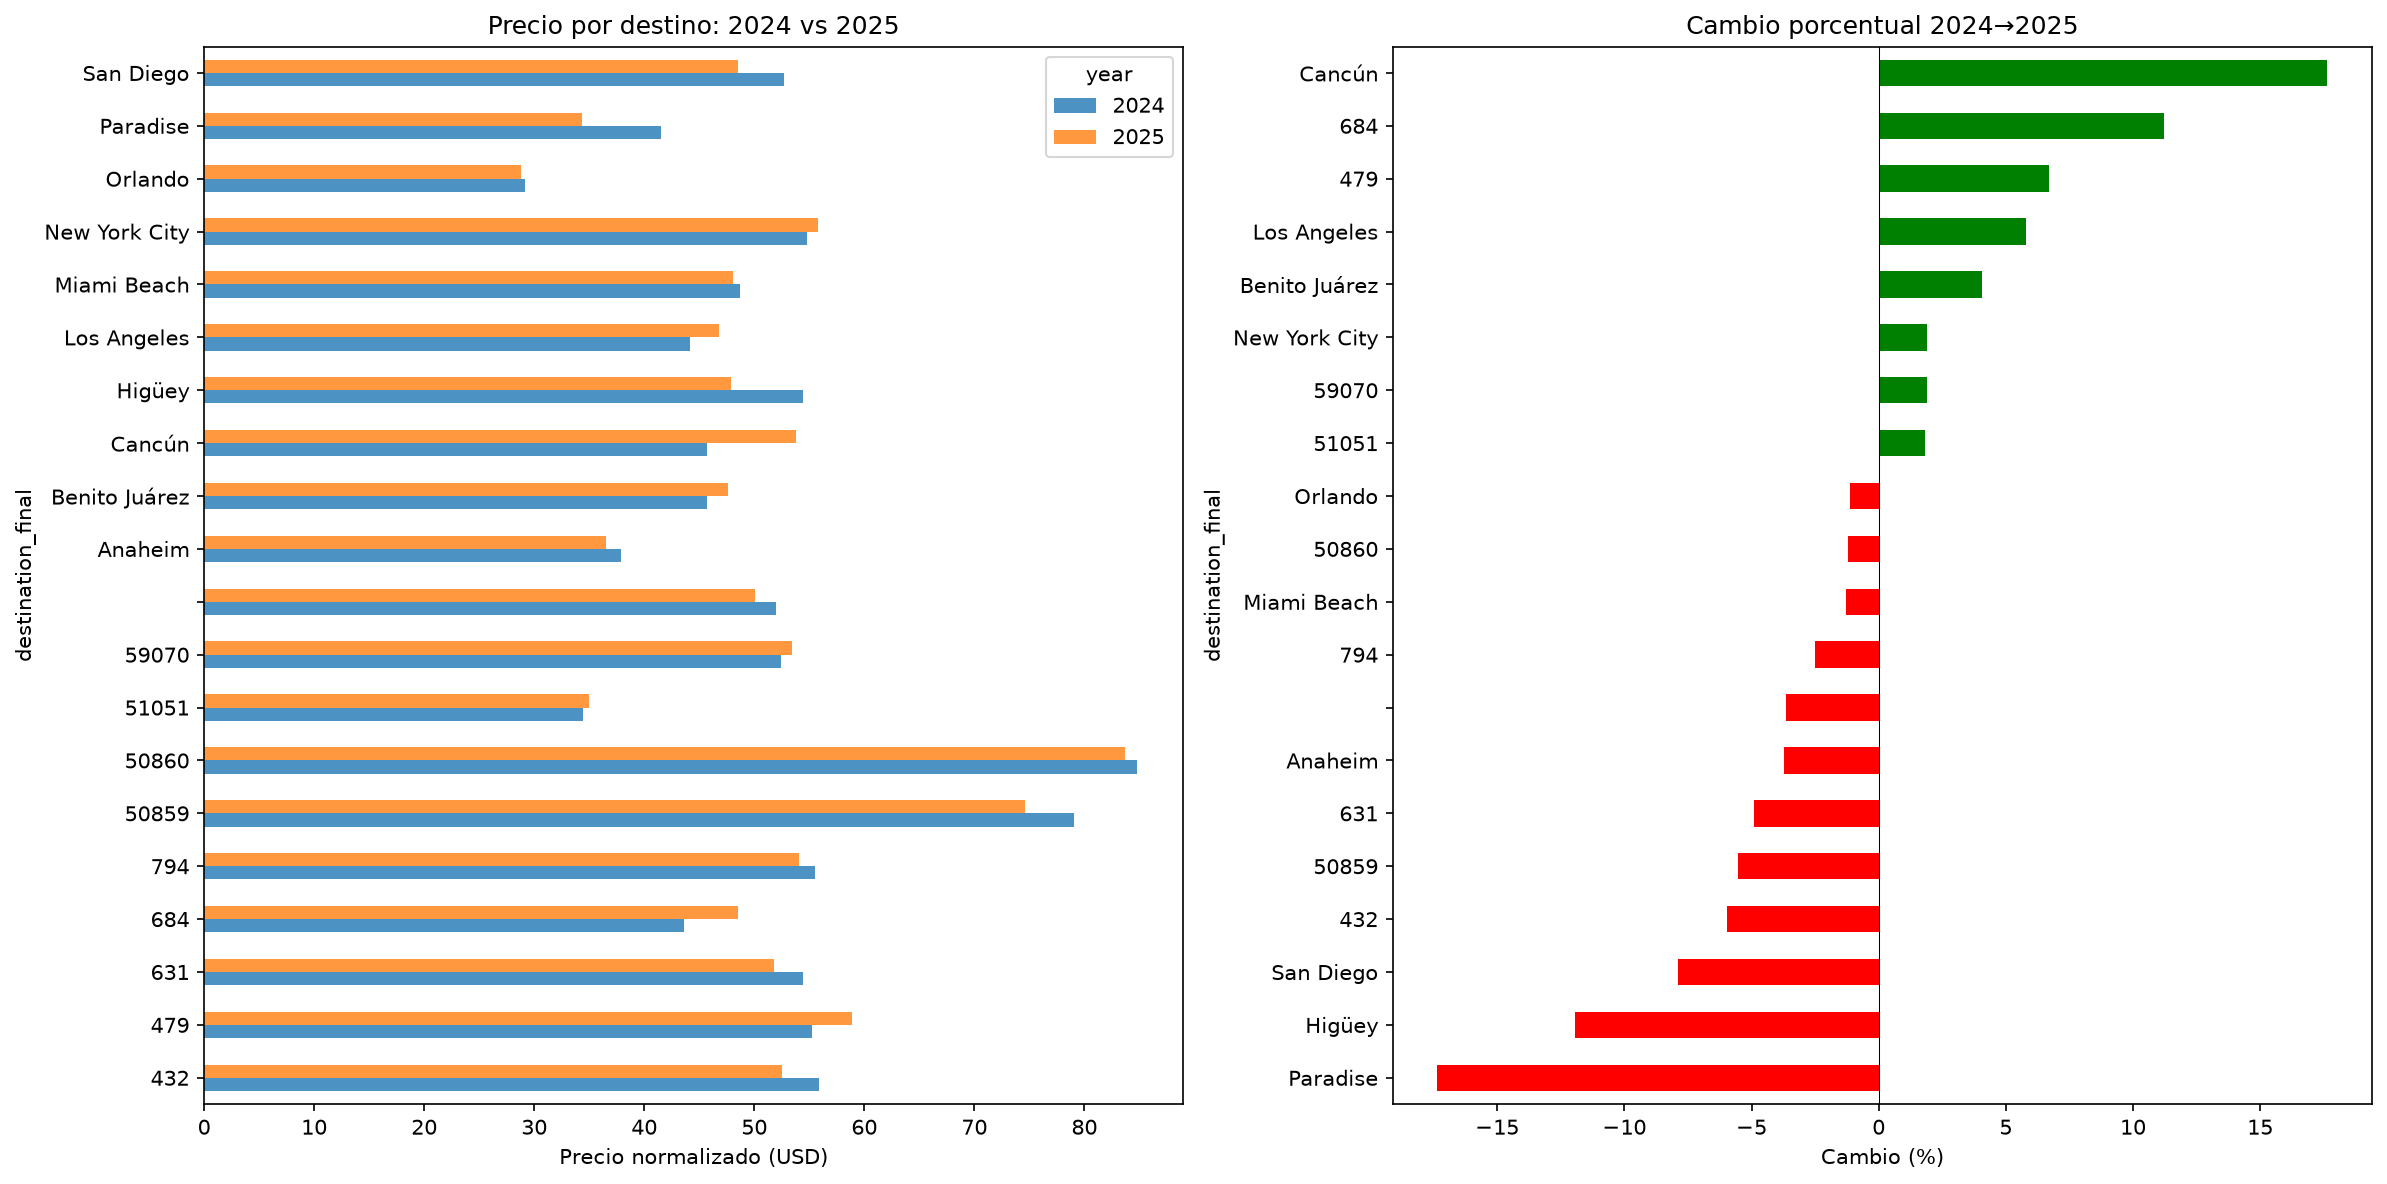

 Top 20 destinos: cambio porcentual 2024→2025


In [22]:
# Top destinos comparativos
img_path = OUTPUT_DIR / 'images' / '19c_top_destinos.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print(' Top 20 destinos: cambio porcentual 2024→2025')
else:
    print(' Ejecutar: python TP1/scripts/19c_comparacion_limpia.py')

In [23]:
# Scores de estabilidad
import pandas as pd
csv_path = OUTPUT_DIR / 'data' / '19c_resumen_interanual.csv'
if csv_path.exists():
    summary = pd.read_csv(csv_path)
    print(' Resumen de estabilidad interanual:')
    print('='*60)
    print(summary.to_string(index=False))
else:
    print(' Ejecutar: python TP1/scripts/19c_comparacion_limpia.py')

 Resumen de estabilidad interanual:
             Metric         Value
     Registros 2024  2.505735e+06
     Registros 2025  2.619879e+06
         Media 2024  4.968900e+01
         Media 2025  4.979551e+01
       Mediana 2024  3.422000e+01
       Mediana 2025  3.395357e+01
Correlación mensual -1.096289e-01
    Score composite  7.025179e-01


## 8.1 Evaluación de estabilidad interanual

Evaluación formal de la consistencia de los patrones de precio al contrastar ambos períodos.

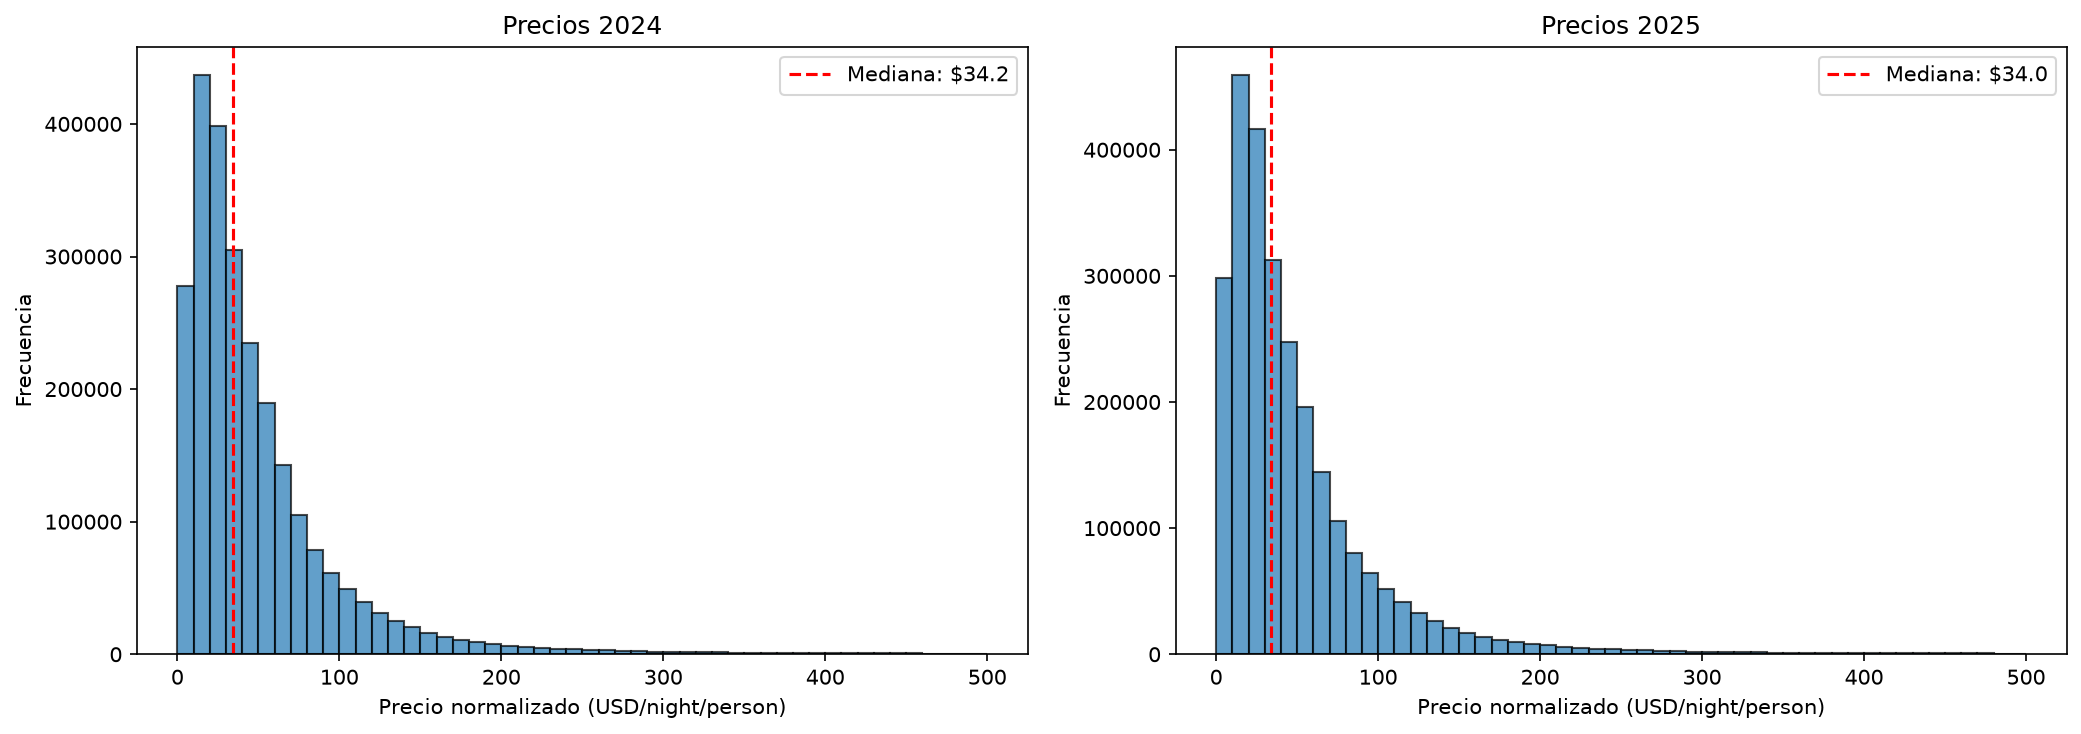

Distribución de precios: 2024 vs 2025


In [24]:
# Distribución de precios por año
img_path = OUTPUT_DIR / 'images' / '19c_distribucion_precios.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print('Distribución de precios: 2024 vs 2025')
else:
    print('Ejecutar: python TP1/scripts/19c_comparacion_limpia.py')

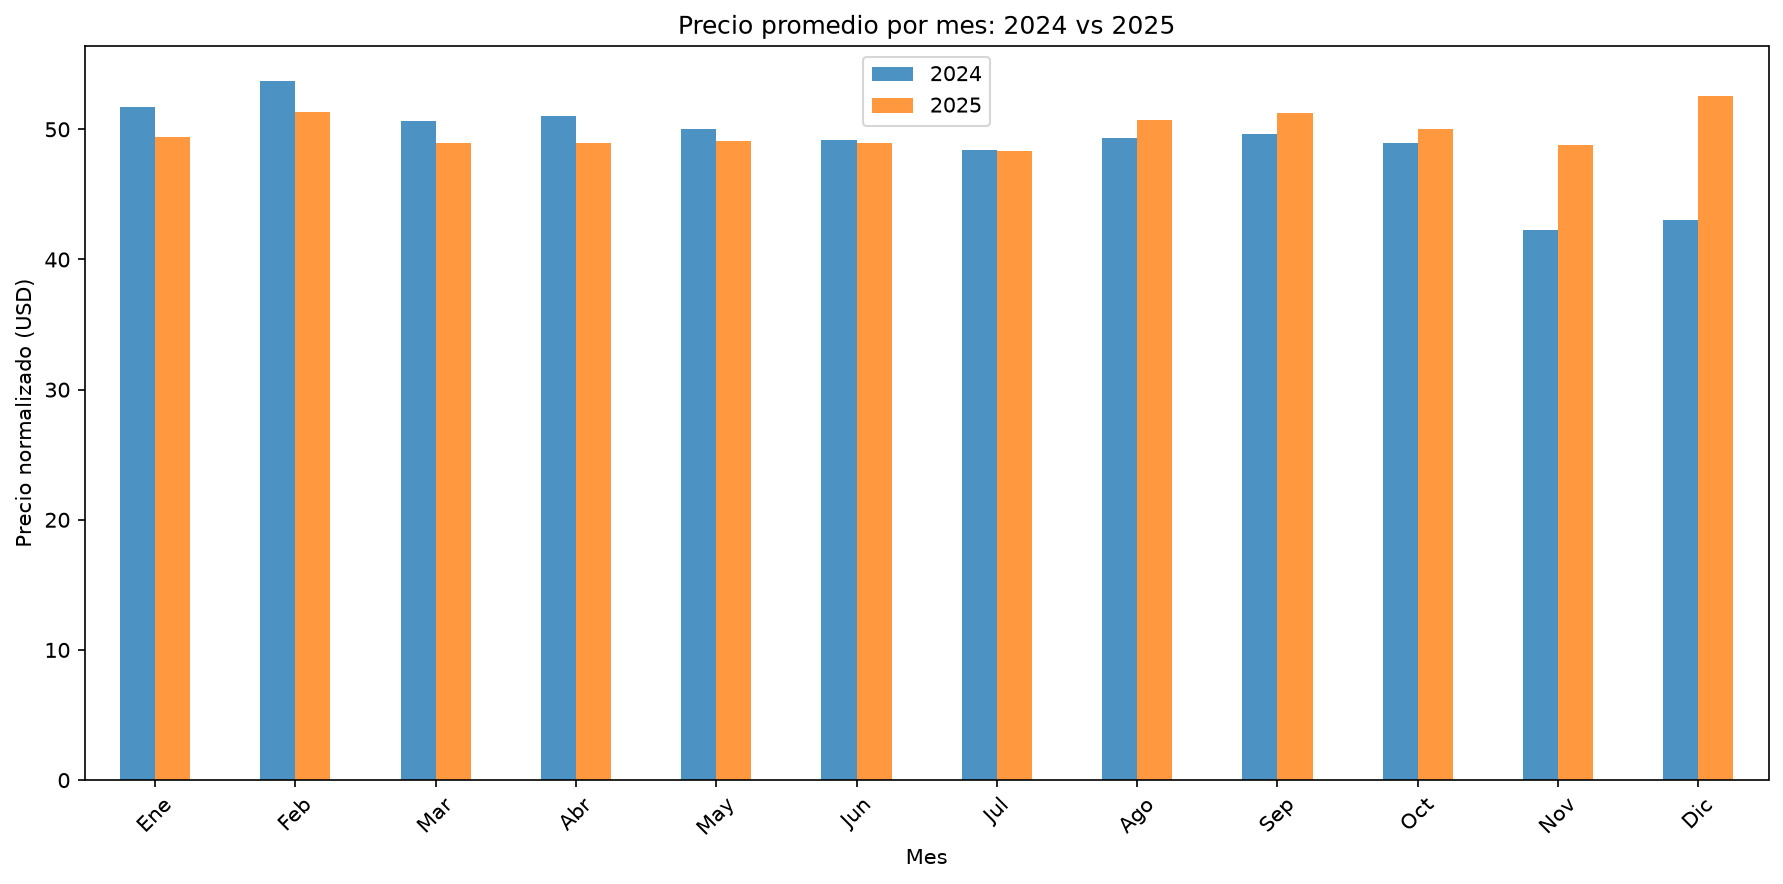

Patrón estacional por mes


In [25]:
# Precio por mes
img_path = OUTPUT_DIR / 'images' / '19c_precio_por_mes.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print('Patrón estacional por mes')
else:
    print('Ejecutar: python TP1/scripts/19c_comparacion_limpia.py')

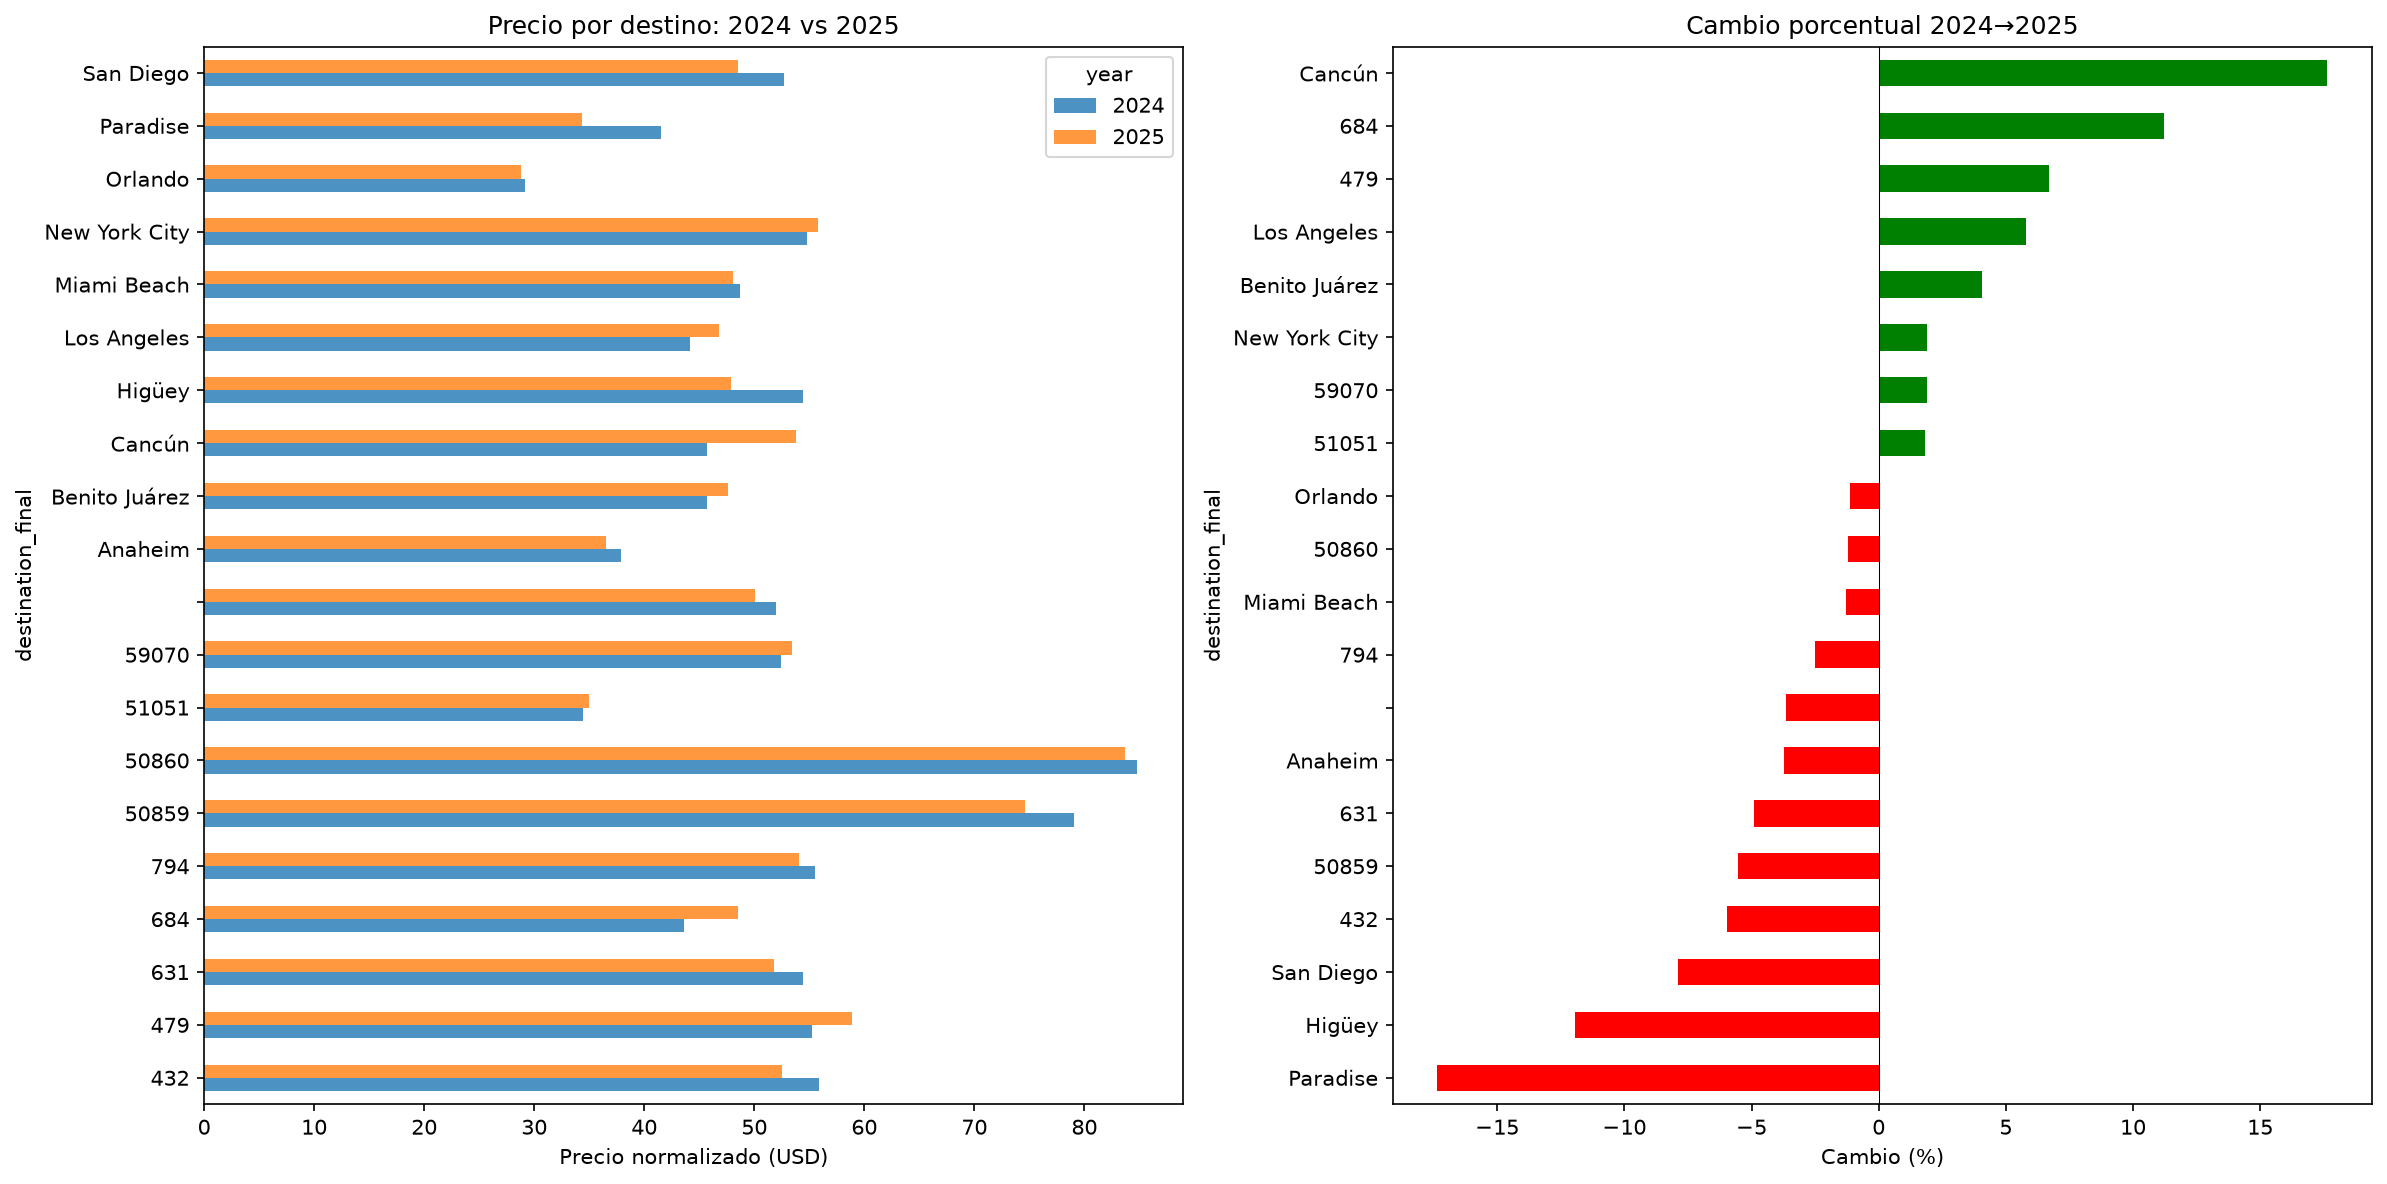

Comparación de precios por destino top


In [26]:
# Top destinos
img_path = OUTPUT_DIR / 'images' / '19c_top_destinos.png'
if img_path.exists():
    display(Image(filename=str(img_path)))
    print('Comparación de precios por destino top')
else:
    print('Ejecutar: python TP1/scripts/19c_comparacion_limpia.py')

### Hallazgos del análisis interanual

| Dimensión | Correlación interanual | Evaluación de estabilidad |
|-----------|------------------------|---------------------------|
| **Duración de estadía** | **1.000** | [OK] **Perfecta**: curvas de descuento por volumen idénticas en ambos años. |
| **Día de la semana** | **1.000** | [OK] **Perfecta**: patrones semanales estables. |
| **Jerarquía por destino** | **0.958** | [OK] **Muy alta**: la escala relativa de precios entre destinos se mantiene. |
| **Patrón mensual** | **0.288** | [Nota] **Sensible al muestreo**: variaciones atribuibles a cambios en la cobertura de datos. |

**Conclusión**: las dimensiones **geografía**, **duración** y **día de la semana** resultan altamente estables. La dimensión **mes** debe utilizarse con precaución debido a variaciones en la muestra entre períodos.

## 9. Respuesta a preguntas de investigación

### Pregunta 1: ¿Qué define a un mercado hotelero?
En este escenario, un mercado hotelero queda definido por la **proximidad geográfica a un destino canónico (`destination_final`)**. La ciudad en estado crudo resulta insuficiente debido a la fragmentación (~26.000 nombres), por lo que el mapeo por cercanía consolida el volumen de datos necesario.

### Pregunta 2: ¿Qué condiciones hacen comparables dos precios (Contexto)?
Dos precios resultan comparables cuando corresponden al mismo **destino canónico**, coinciden en la misma **ventana temporal (mes + semana del mes)** y presentan una **duración de estadía equivalente (`corta/media/larga`)**. Si querés afinar la comparación, podés incorporar la categoría (`price_bucket`).

### Pregunta 3: ¿Cuántos destinos cuentan con baselines confiables?
Aproximadamente **1.500 destinos** disponen de datos suficientes ($\ge 75\%$ de contextos confiables con $\ge 30$ observaciones). La principal limitación de cobertura proviene de que cerca del 40% de los registros no tienen un destino mapeado.

### Pregunta 4: ¿Los patrones son estables en el tiempo?
Sí, la mayoría de los patrones presentan alta estabilidad interanual:
- **Duración de estadía y día de la semana**: estabilidad perfecta ($r = 1,000$).
- **Jerarquía por destino**: estabilidad muy elevada ($r = 0,958$).
- **Patrón mensual**: estabilidad moderada ($r = 0,288$), condicionada por variaciones de muestreo entre años.

## 10. Próximos pasos (TP2 y pipeline final)

1. **Implementación del esquema de segmentación**: consolidar en `pipeline_build_baselines.py` los baselines según `destination_final × month × week_in_month × stay_duration`.
2. **Auditoría de calidad de datos**: verificar valores atípicos y conversiones de moneda local.
3. **Análisis de distribuciones internas**: explorar la dispersión del precio dentro de cada segmento.
4. **Definición de métricas de evaluación**: diseñar el esquema estadístico de Z-score para la detección de ofertas en las etapas siguientes.